In [1]:
import os
import pathlib

import warnings
warnings.filterwarnings("ignore")

import FunctionLib as FL
from tqdm import tqdm

import numpy as np
import pandas as pd
import scipy
from scipy.interpolate import interp1d

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['font.family'] = 'serif'
config = {
    "font.size": 18,
    "font.family": "serif",
    "figure.figsize": (25, 14),

    "axes.titlesize": 28,        # ax.set_title fontsize
    "axes.labelsize": 24,        # ax.set_xlabel/ylabel fontsize
    "legend.fontsize": 20,       # ax.legend fontsize
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,

    "axes.linewidth": 2,         # 对应 ax.spines...linewidth
    "axes.edgecolor": "black",   # 对应 ax.spines...color

    "xtick.direction": "in",     # direction='in'
    "ytick.direction": "in",
    "xtick.top": True,           # ax.xaxis.set_ticks_position('both')
    "ytick.right": True,         # ax.yaxis.set_ticks_position('both')

    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.width": 2,      # which='both' implies minor too
    "ytick.minor.width": 2,

    "xtick.major.size": 6,       # length=6 major
    "ytick.major.size": 6,
    "xtick.minor.size": 3,       # length=3 minor
    "ytick.minor.size": 3,
}
mpl.rcParams.update(config)

import astropy
import astropy.units as u

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(('./DJAV4.2Catalog.pkl'))
print(DJAv4Catalog.sample_num())
DJAv4Catalog.to_dataframe()


1102


,survey_id_subid,prism_filepath,prism_redshift,determined_redshift,grating_filepaths,grating_redshifts,file_count,available_filters,properties,survey_id,sample_flag,reason_for_exclusion,grating_within_coverage,grating_slitloss_correction,lines_fit,line_ratios,dust_curve_parameters
0,snh0pe-v4_4446_102,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.2259,0.2259,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",3,"{g235m-f170lp, g140m-f100lp, prism-clear}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
1,snh0pe-v4_4446_143,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.6318,1.6311,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.6313, 'g235m-f170lp': 1.6309}",3,"{g235m-f170lp, g140m-f100lp, prism-clear}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
2,snh0pe-v4_4446_285,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.4446,0.4462,{'g235m-f170lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g235m-f170lp': 0.4462, 'g140m-f100lp': 0.4462}",3,"{g235m-f170lp, g140m-f100lp, prism-clear}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
3,snh0pe-v4_4446_29,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7834,1.77975,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7799, 'g235m-f170lp': 1.7796}",3,"{g235m-f170lp, g140m-f100lp, prism-clear}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
4,snh0pe-v4_4446_123,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7855,1.7855,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7855, 'g235m-f170lp': 1.7851}",3,"{g235m-f170lp, g140m-f100lp, prism-clear}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43037,glimpse-obs02-v4_9223_9152,None,None,5.5385,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 5.5385},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,[no_prism_spectrum],{},{},{},{},{}
43038,glimpse-obs02-v4_9223_98001,None,None,2.6322,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 2.6322},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[redshift_below_3, no_prism_spectrum]",{},{},{},{},{}
43039,glimpse-obs02-v4_9223_47046,None,None,4.3554,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 4.3554},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,[no_prism_spectrum],{},{},{},{},{}
43040,glimpse-obs02-v4_9223_45350,None,None,1.3675,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 1.3675},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[redshift_below_3, no_prism_spectrum]",{},{},{},{},{}


---
## Average all the spectrum.

In [41]:
averager=FL.SpectrumAverager()
for surveyid_subid, catalog in tqdm(DJAv4Catalog.catalog_iterator(), total=len(DJAv4Catalog.catalog)):
    if not catalog['sample_flag']:
        continue

    averager.load_spectrum_catalog([surveyid_subid],DJAv4Catalog)

averager.create_common_wavelength_grid(wavelength_range=(1350,8000),grid_size=10)
averager.interpolate_spectra(interpolation_method='linear')
averager.spectrum_normalization_within_range(wavelength_range=(5450,5550))
averager.compute_average_spectrum(method='mean', ignore_nan=True, use_percentile_filter=True, lower_percentile=16, upper_percentile=84)
fig,ax=averager.plot_average_spectrum(show_individual=True, show_average=True, show_error=True, figsize=(25,14), alpha=0.1, show_normalization_point=True, reference_wavelength=5500.0,if_show=False)

 53%|█████▎    | 22615/43042 [00:04<00:04, 4732.43it/s]


KeyboardInterrupt: 

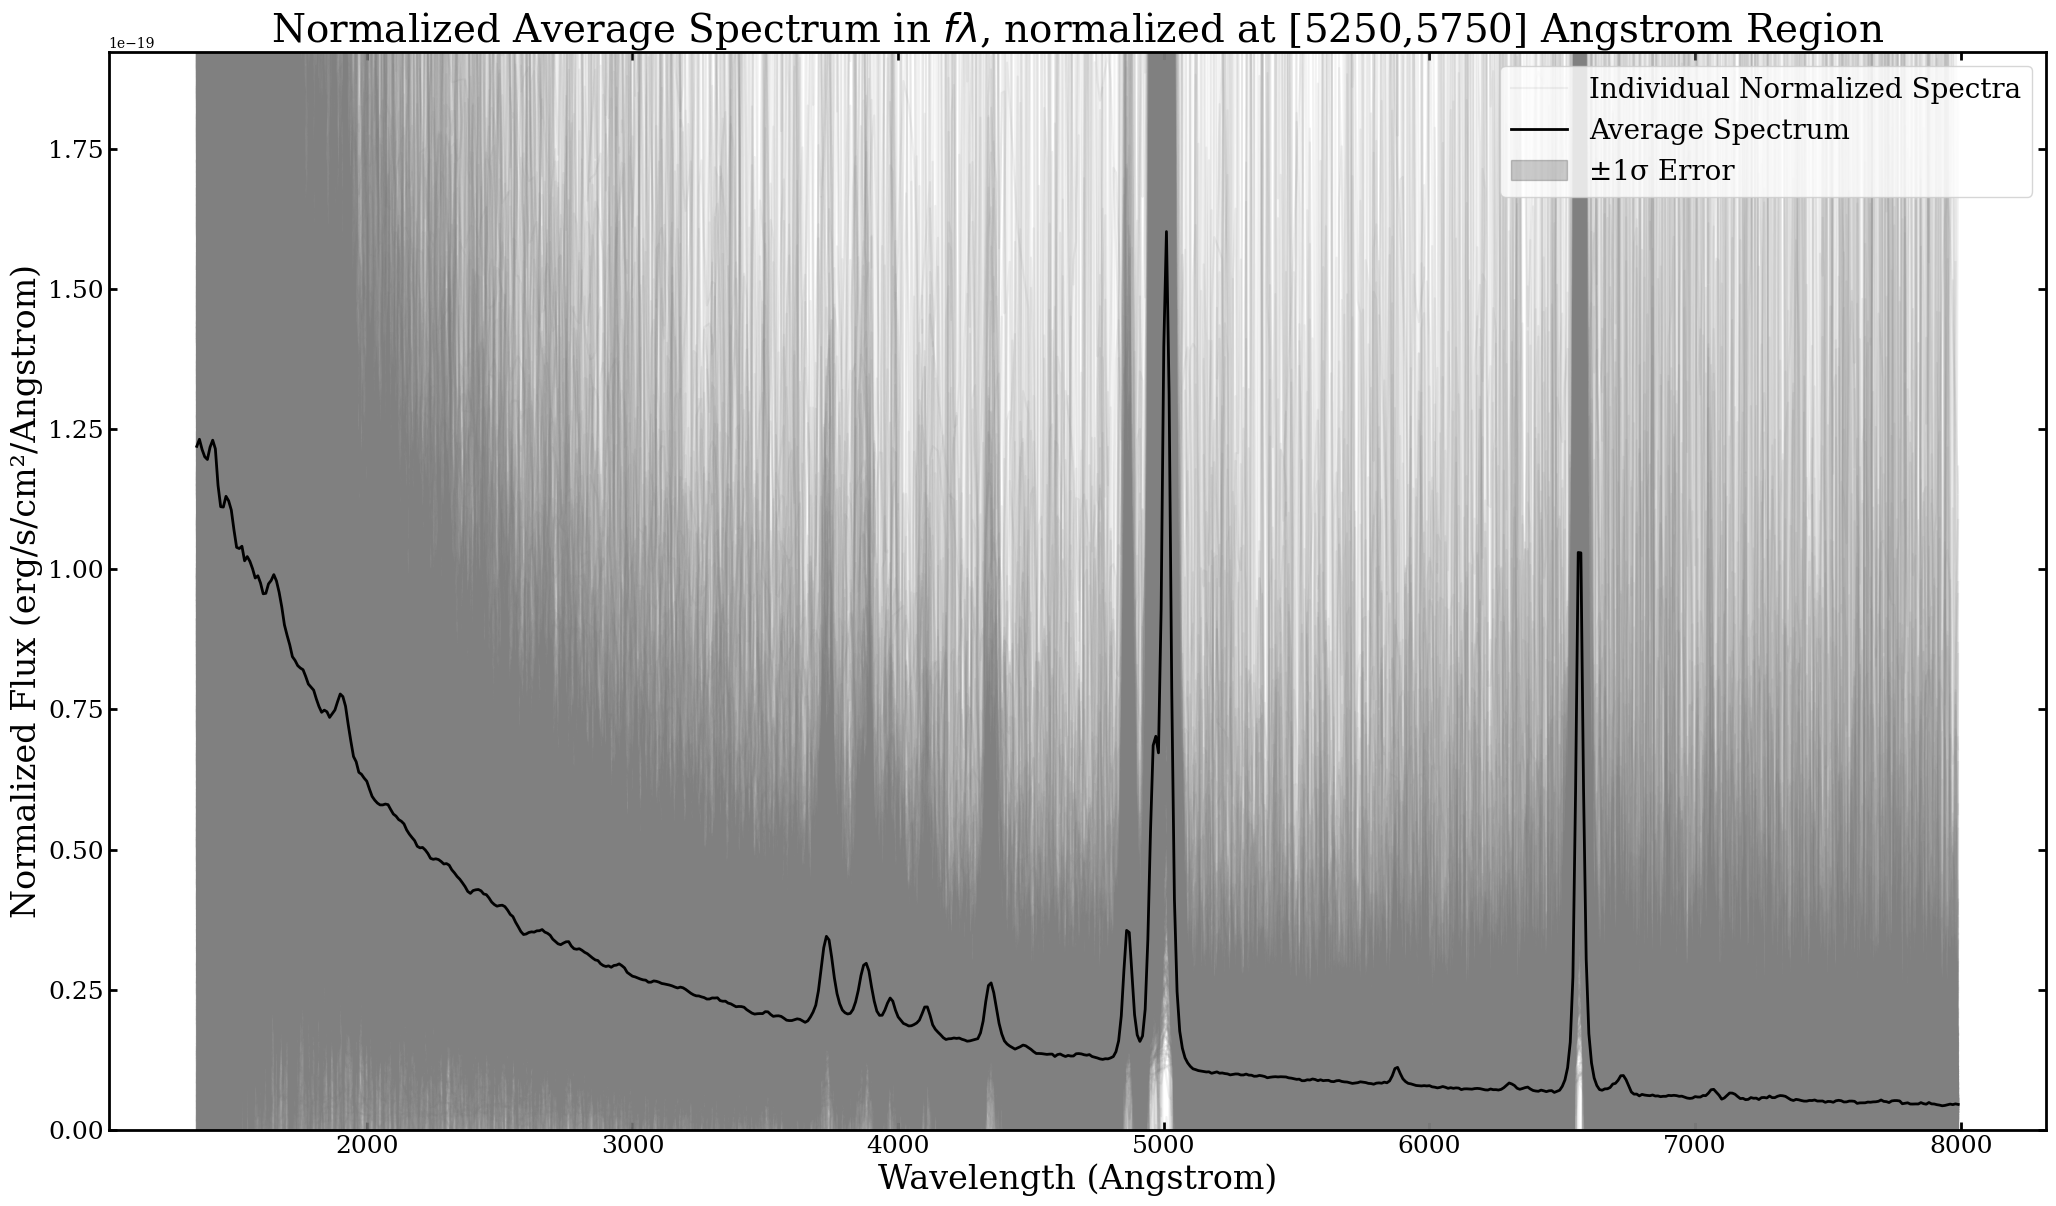

In [4]:
fig,ax=averager.plot_average_spectrum(show_individual=True, show_average=True, show_error=True, figsize=(25,14), alpha=0.1, show_normalization_point=False, reference_wavelength=5500.0,if_show=False)
ax.set_title('Normalized Average Spectrum in $f\\lambda$, normalized at [5250,5750] Angstrom Region', fontsize=28)
plt.savefig('Region_Normalized_Average_Spectrum_f_lambda.pdf', bbox_inches='tight', dpi=300)

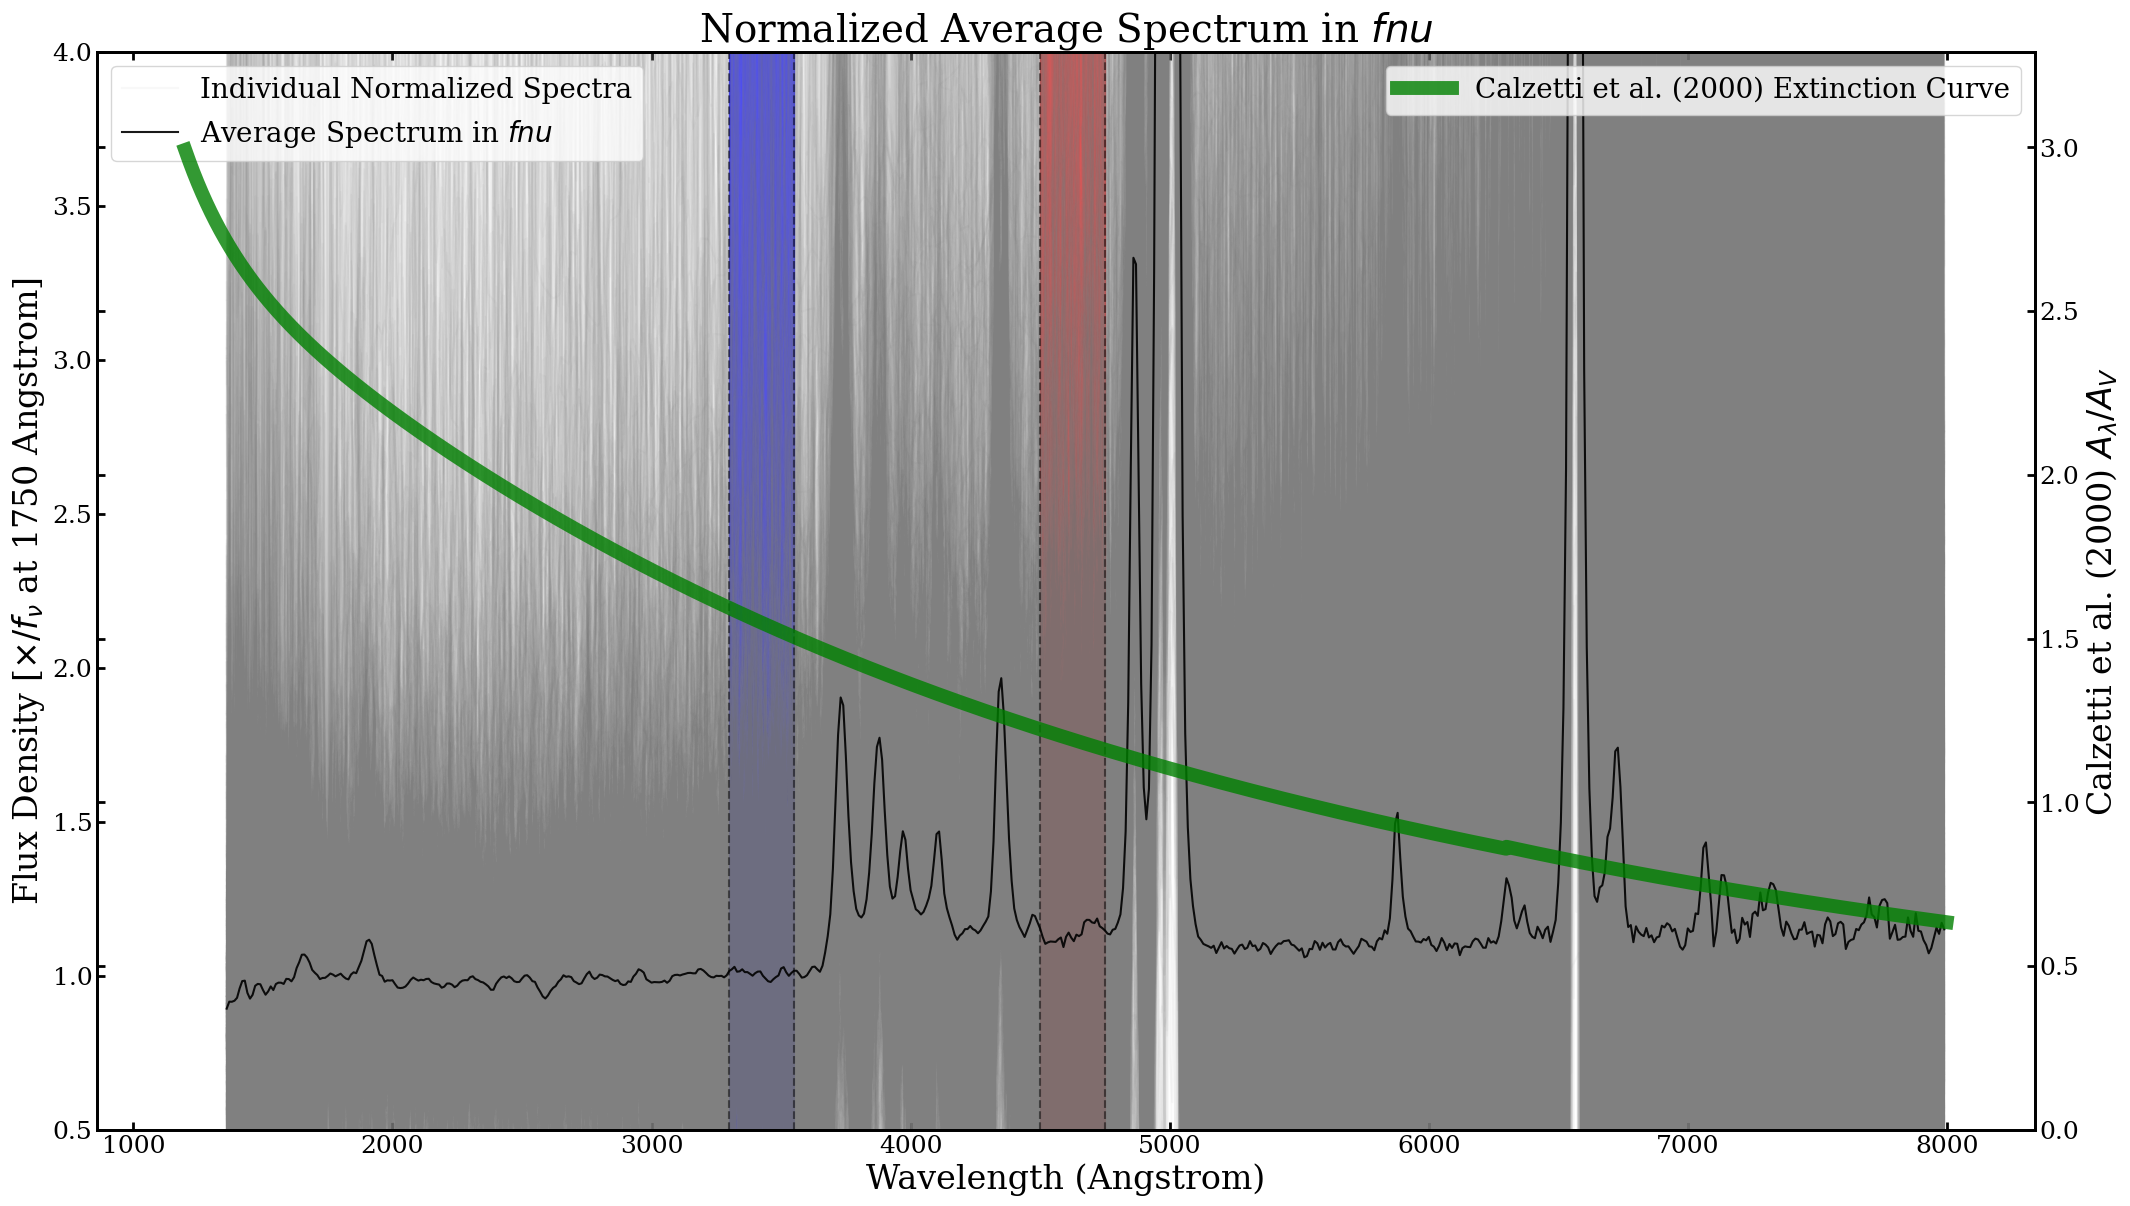

In [ ]:
fig, ax = plt.subplots(figsize=(25,14))

for normalized_flux in averager.normalized_fluxes:
    f_nu=normalized_flux*u.erg/u.s/u.cm**2/u.AA
    f_nu=f_nu.to(u.Jy, equivalencies=u.spectral_density(averager.common_wavelength*u.AA))
    f_nu_1750=f_nu[np.abs(averager.common_wavelength-1750).argmin()]
    f_nu=f_nu.value/f_nu_1750.value
    ax.plot(averager.common_wavelength, f_nu, color='gray', alpha=0.05, label='Individual Normalized Spectra' if 'Individual Normalized Spectra' not in ax.get_legend_handles_labels()[1] else "")

wavelength=averager.common_wavelength*u.AA
flux=averager.average_flux*u.erg/u.s/u.cm**2/u.AA
f_nu=flux.to(u.Jy, equivalencies=u.spectral_density(wavelength))
f_nu_1750=f_nu[np.abs(wavelength.value-1750).argmin()]
f_nu=f_nu.value/f_nu_1750.value
ax.plot(wavelength, f_nu, color='black', alpha=0.9, label='Average Spectrum in $fnu$')

ax.set_xlabel('Wavelength (Angstrom)', fontsize=24)
ax.set_ylabel(r'Flux Density [$\times / f_\nu$ at 1750 Angstrom]', fontsize=24)
ax.legend(fontsize=20,loc='best')
ax.set_title('Normalized Average Spectrum in $fnu$', fontsize=28)
ax.set_ylim(0.5,4)
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18)
ax.yaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18)
ax.xaxis.set_tick_params(length=6, which='major')
ax.xaxis.set_tick_params(length=3, which='minor')
ax.yaxis.set_tick_params(length=6, which='major')
ax.yaxis.set_tick_params(length=3, which='minor')
ax.axvline(4750, color='k', linestyle='--', alpha=0.5)
ax.axvline(4500, color='k', linestyle='--', alpha=0.5)
ax.fill_betweenx([0,4], 4500, 4750, color='red', alpha=0.7)
ax.axvline(3300, color='k', linestyle='--', alpha=0.5)
ax.axvline(3550, color='k', linestyle='--', alpha=0.5)
ax.fill_betweenx([0,4], 3300, 3550, color='blue', alpha=0.7)


twinx=ax.twinx()
twinx.set_ylabel(r'Calzetti et al. (2000) $A_\lambda / A_V$', fontsize=24)
calzetti_wavelengths = np.arange(1200, 8000, 1)  # Angstrom
calzetti_wavelengths_um = calzetti_wavelengths / 1e4

k_lambda = np.piecewise(calzetti_wavelengths_um,
    [calzetti_wavelengths_um < 0.63,
     (calzetti_wavelengths_um >= 0.63) & (calzetti_wavelengths_um <= 2.20)],
    [lambda x: 2.659 * (-2.156 + 1.509 / x - 0.198 / (x**2) + 0.011 / (x**3)) + 4.05,
     lambda x: 2.659 * (-1.857 + 1.040 / x) + 4.05]
)
A_lambda_over_A_V = k_lambda / 4.05
twinx.plot(calzetti_wavelengths, A_lambda_over_A_V, color='green', linestyle='-',linewidth=10, alpha=0.8, label='Calzetti et al. (2000) Extinction Curve')
twinx.set_ylim(0, np.max(A_lambda_over_A_V)*1.1)
twinx.spines['bottom'].set_linewidth(2)
twinx.spines['top'].set_linewidth(2)
twinx.spines['left'].set_linewidth(2)
twinx.spines['right'].set_linewidth(2)
twinx.spines['bottom'].set_color('black')
twinx.spines['top'].set_color('black')
twinx.spines['left'].set_color('black')
twinx.spines['right'].set_color('black')
twinx.yaxis.set_ticks_position('both')
twinx.xaxis.set_ticks_position('both')
twinx.xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18)
twinx.yaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18)
twinx.xaxis.set_tick_params(length=6, which='major')
twinx.xaxis.set_tick_params(length=3, which='minor')
twinx.yaxis.set_tick_params(length=6, which='major')
twinx.yaxis.set_tick_params(length=3, which='minor')
twinx.legend(fontsize=20, loc='upper right')





plt.savefig('Normalized_Average_Spectrum_fnu_Calzetti2000_Extinction_Curve.pdf', bbox_inches='tight', dpi=300)


plt.show()

---
## Binning the spectrum and average different attenuation spectrum.

In [3]:

group_conditions = [(-0.2,0.02),(0.02,0.10), (0.10,0.2),(0.2,0.3),(0.3,0.40),(0.40,0.6)]

def group_condition_func(balmer_decrement):
    for i, (low, high) in enumerate(group_conditions):
        if low < balmer_decrement <= high:
            return i
    return 6

In [4]:
group0_averager=FL.SpectrumAverager()
group1_averager=FL.SpectrumAverager()
group2_averager=FL.SpectrumAverager()
group3_averager=FL.SpectrumAverager()
group4_averager=FL.SpectrumAverager()
group5_averager=FL.SpectrumAverager()
group6_averager=FL.SpectrumAverager()


for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator():
    if not catalog['sample_flag']:
        continue

    uv_slope_value=catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters']['exponent']
    halpha_flux=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['halpha_flux']
    hbeta_flux=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['hbeta_flux']
    balmer_decrement=np.log(halpha_flux/hbeta_flux/2.86)
    group_index=group_condition_func(balmer_decrement)
    if group_index==-1:
        continue

    averager_to_use='group'+str(group_index)+'_averager'
    globals()[averager_to_use].load_spectrum_catalog([surveyid_subid],DJAv4Catalog)




In [5]:
for i in range(7):
    averager_to_use='group'+str(i)+'_averager'
    globals()[averager_to_use].create_common_wavelength_grid(wavelength_range=(1350,8000),grid_size=10)
    globals()[averager_to_use].interpolate_spectra(interpolation_method='linear')
    globals()[averager_to_use].spectrum_normalization_within_range(wavelength_range=(5400,5600),target_flux=1.e-19)
    globals()[averager_to_use].compute_average_spectrum(method='median', ignore_nan=True, use_percentile_filter=True, lower_percentile=16, upper_percentile=84)
    # globals()[averager_to_use].plot_average_spectrum(show_individual=True, show_average=True, show_error=True, figsize=(25,14), alpha=0.3, show_normalization_point=True, reference_wavelength=5500.0,ylim=(0,2e-18))

Spectrum index 20 has invalid normalization factor. Skipping.


In [45]:
def power_law(x, amplitude, exponent):
    """
    Power law function for fitting.
    """
    return amplitude * (x ** exponent)

def fit_power_law(restframe_wave, restframe_flux_lambda, initial_guess=(1e-19, -1.0)):
    """
    Fit a power law to the given wavelengths and fluxes.
    """

    fit_mask = (restframe_wave.data >= 1407) & (restframe_wave.data <= 2580)
    wave_to_fit = restframe_wave[fit_mask].data
    flux_to_fit = restframe_flux_lambda[fit_mask].data

    # if np.any(error_to_fit <= 0):
    #     print("Warning: Non-positive error values found. These will be ignored in the fit.")
    #     valid_error_mask = error_to_fit > 0
    #     wave_to_fit = wave_to_fit[valid_error_mask]
    #     flux_to_fit = flux_to_fit[valid_error_mask]
    #     error_to_fit = error_to_fit[valid_error_mask]

    if np.any(np.isnan(flux_to_fit)) :
        print("Warning: NaN values found in flux or error arrays. These will be ignored in the fit.")
        valid_nan_mask = ~np.isnan(flux_to_fit)
        wave_to_fit = wave_to_fit[valid_nan_mask]
        flux_to_fit = flux_to_fit[valid_nan_mask]

    fit_successful = False
    if len(wave_to_fit) > 2:
        try:
            initial_guess = [np.median(flux_to_fit), -1.5]
            popt, pcov = scipy.optimize.curve_fit(
                power_law,
                xdata=wave_to_fit,
                ydata=flux_to_fit,
                p0=initial_guess,
                absolute_sigma=True,
                maxfev=500000
            )

            fit_amplitude, fit_exponent = popt
            perr = np.sqrt(np.diag(pcov))
            fit_amplitude_err, fit_exponent_err = perr
            fit_successful = True

            # print("\n--- Power-law Fit Results ---")
            # print(f"  Amplitude: {fit_amplitude:.3e} ± {fit_amplitude_err:.3e}")
            # print(f"  Exponent:  {fit_exponent:.3f} ± {fit_exponent_err:.3f}")
            # print("---------------------------\n")
            return fit_amplitude, fit_amplitude_err, fit_exponent, fit_exponent_err

        except RuntimeError as e:
            print(f"Fit failed for {surveyid_subid}: {e}")
            return None


In [46]:
decrement_list=[]
uv_list=[]
for i in range(6):
    averager_to_use='group'+str(i)+'_averager'
    averager=globals()[averager_to_use]
    spectrum0=FL.Spectrum_1d(averager.common_wavelength*u.AA, 0, None, averager.average_flux*1e19*u.erg/u.s/u.cm**2/u.AA)
    alpharestFrameWavelength=6563.0*astropy.units.AA
    spectrum0.set_boundarys(alpharestFrameWavelength-75.0*astropy.units.AA, alpharestFrameWavelength+50.0*astropy.units.AA)
    fitting=FL.SpectralLineFitter(spectrum0, alpharestFrameWavelength)
    alpha=fitting.fit_single_gaussian_with_offset()['integrated_flux']

    alpharestFrameWavelength=4863.0*astropy.units.AA
    spectrum0.set_boundarys(alpharestFrameWavelength-75.0*astropy.units.AA, alpharestFrameWavelength+50.0*astropy.units.AA)
    fitting=FL.SpectralLineFitter(spectrum0, alpharestFrameWavelength)
    beta=fitting.fit_single_gaussian_with_offset()['integrated_flux']

    uv_region_wavelengths = (1407.0, 2580.0) * astropy.units.AA
    spectrum0.set_boundarys(uv_region_wavelengths[0], uv_region_wavelengths[1])
    powerlaw_params=fit_power_law(spectrum0.processing_wavelengths, spectrum0.processing_flux_lambda)
    print(powerlaw_params)

    balmer=(alpha/beta)
    decrement=np.log(balmer/2.86)
    uv=(powerlaw_params[2])
    decrement_list.append(decrement)
    uv_list.append(uv)

(np.float64(49001362.72788532), np.float64(21916737.35718999), np.float64(-2.0549672528890803), np.float64(0.059929407258736335))
(np.float64(18050856.816108316), np.float64(9564607.432758069), np.float64(-1.9452676643400646), np.float64(0.0709406364400331))
(np.float64(2738274.641830931), np.float64(1658253.8761981502), np.float64(-1.7134231142106129), np.float64(0.08094127287100635))
(np.float64(516049.7015045886), np.float64(389071.59032247623), np.float64(-1.5215715575371938), np.float64(0.10062450195742229))
(np.float64(1157830.814986226), np.float64(987252.7288424121), np.float64(-1.6448017099464733), np.float64(0.11391005070549194))
(np.float64(155751.24961127178), np.float64(162855.30577442996), np.float64(-1.4063028910109705), np.float64(0.1394280481450383))


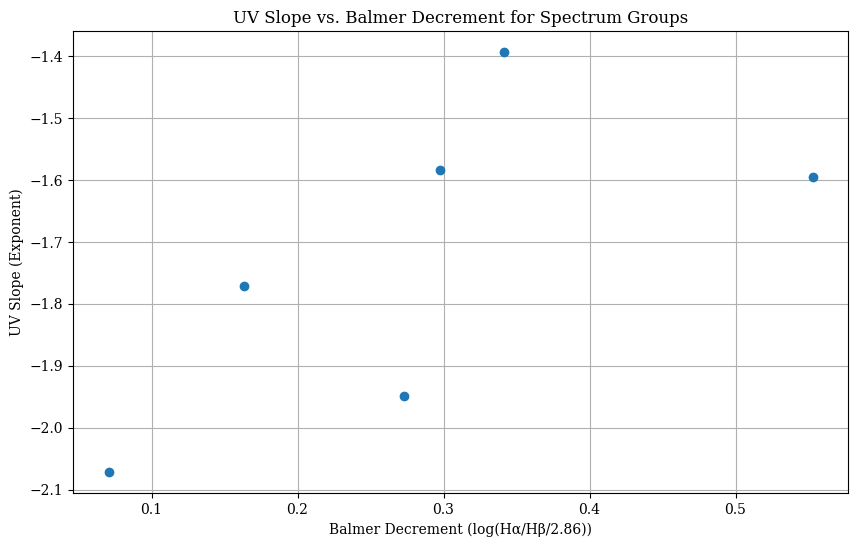

In [8]:
plt.figure(figsize=(10,6))
plt.plot(decrement_list, uv_list, marker='o', linestyle='None')
plt.xlabel('Balmer Decrement (log(Hα/Hβ/2.86))')
plt.ylabel('UV Slope (Exponent)')
plt.title('UV Slope vs. Balmer Decrement for Spectrum Groups')
plt.grid(True)
plt.show()

---
## attenuation curve

In [6]:

group_conditions = [(-0.2,0.02),(0.02,0.10), (0.10,0.2),(0.2,0.3),(0.3,0.40),(0.40,0.6)]
group_decrement_list=[]

for i in range(6):
    decrement_list=[]

    for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator():
        if not catalog['sample_flag']:
            continue

        uv_slope_value=catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters']['exponent']
        halpha_flux=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['halpha_flux']
        hbeta_flux=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['hbeta_flux']
        balmer_decrement=np.log(halpha_flux/hbeta_flux/2.86)
        group_index=group_condition_func(balmer_decrement)
        if group_index!=i:
            continue
        if group_index==-1:
            continue

        decrement_list.append(balmer_decrement)

    group_decrement_list.append(np.mean(decrement_list))



In [8]:
model_spectra=group0_averager.average_flux*u.erg/u.s/u.cm**2/u.AA
tau_lambda_list=[]
Q_lambda_list=[]

for i in range(1,6):
    averager_to_use='group'+str(i)+'_averager'
    tau_lambda_list=[]
    groupi_averager=globals()[averager_to_use]
    tau_lambda=-np.log( (groupi_averager.average_flux)/(group0_averager.average_flux) )
    tau_lambda_list.append(tau_lambda)
    Q_lambda=tau_lambda/ (group_decrement_list[i]-group_decrement_list[0])
    Q_lambda_list.append(Q_lambda)

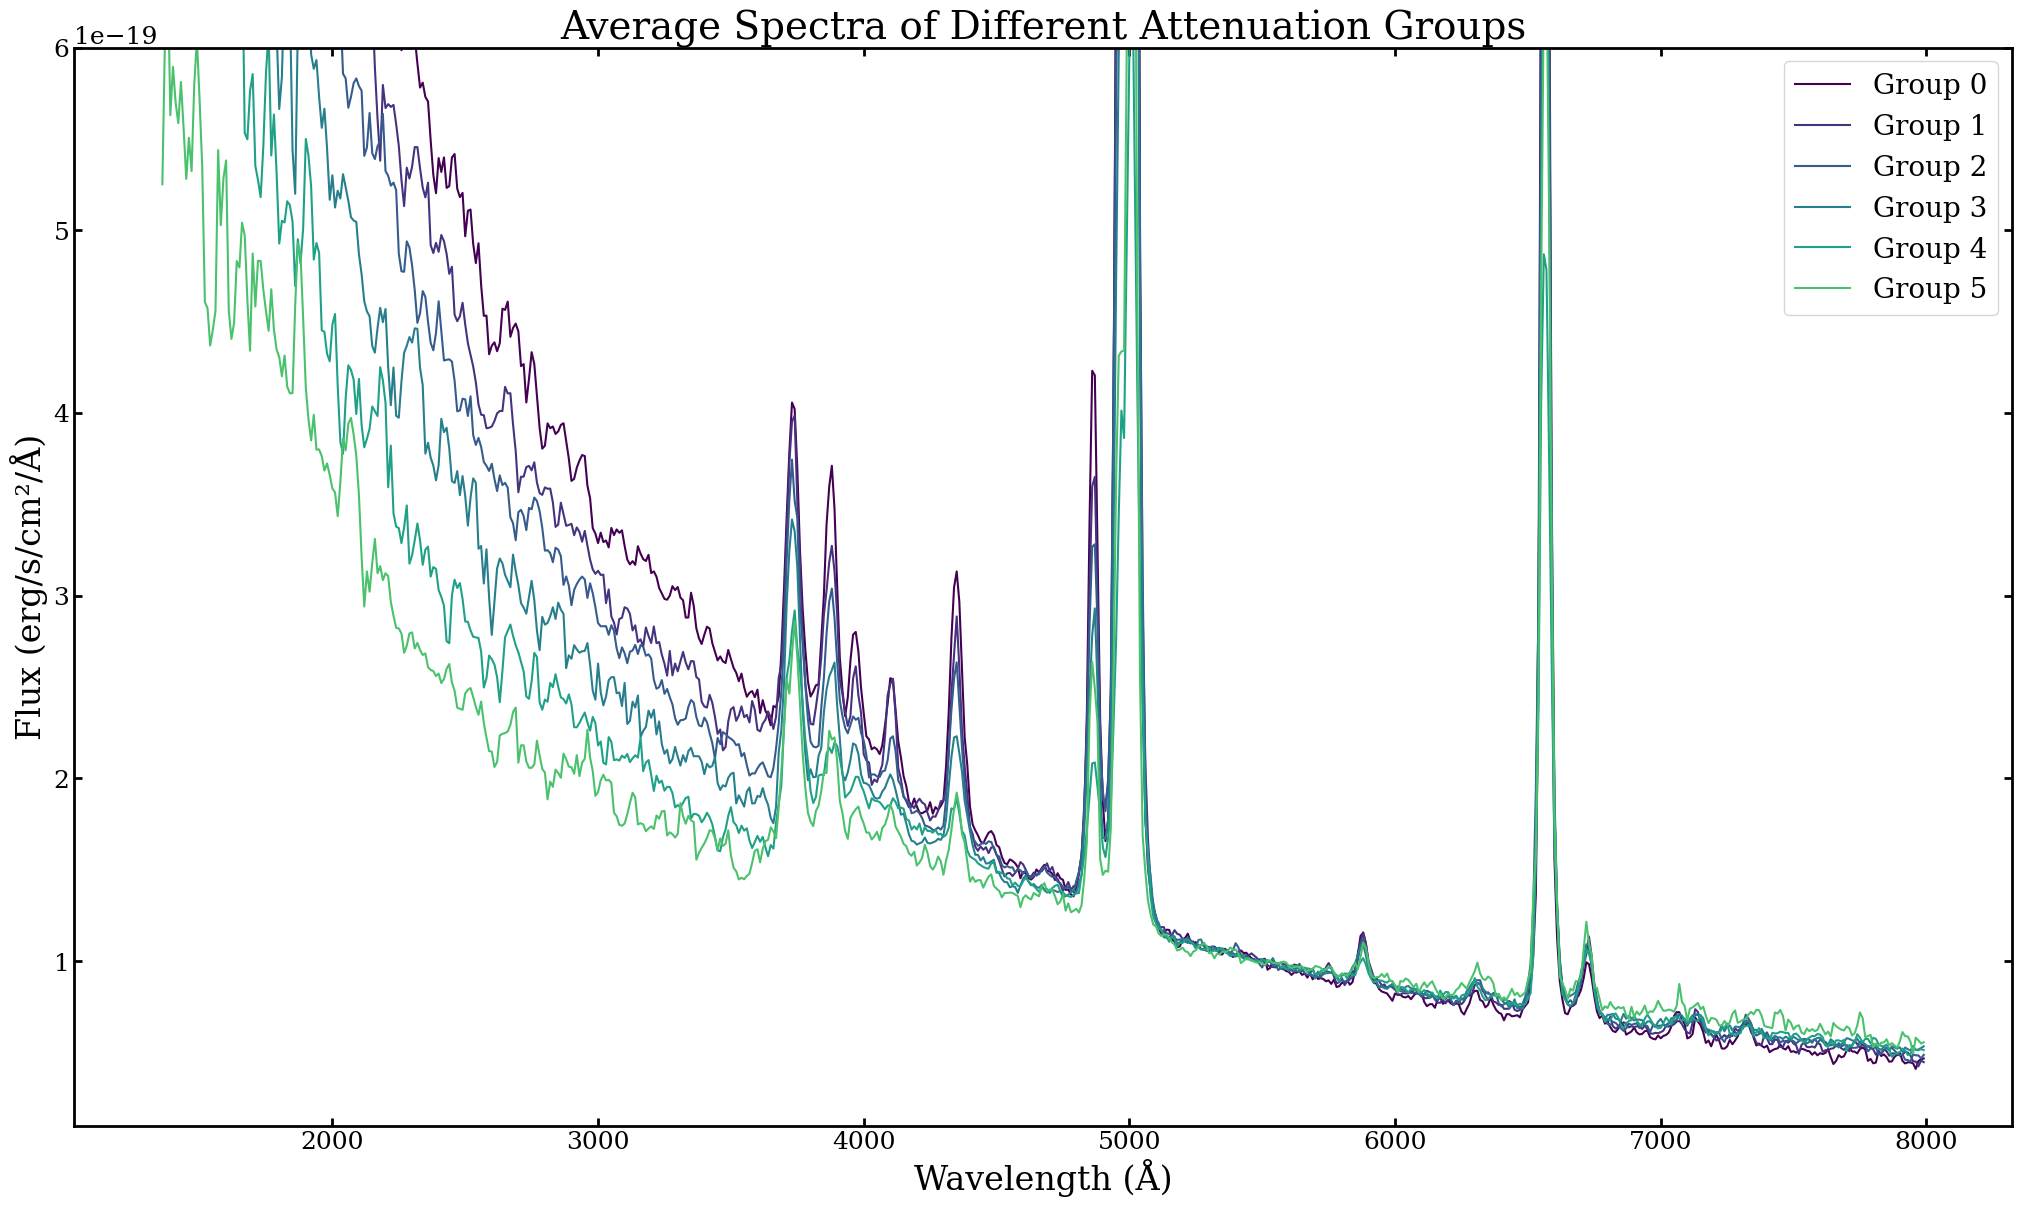

In [9]:
fig, ax=plt.subplots(figsize=(25,14))
colors=plt.cm.viridis(np.linspace(0,7))
for i in range(6):
    averager_to_use='group'+str(i)+'_averager'
    averager=globals()[averager_to_use]
    ax.plot(averager.common_wavelength, averager.average_flux, color=colors[i], label='Group '+str(i))
ax.set_xlabel('Wavelength (Å)', fontsize=24)
ax.set_ylabel('Flux (erg/s/cm²/Å)', fontsize=24)
ax.legend(fontsize=20)

ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18)
ax.yaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18)
ax.xaxis.set_tick_params(length=6, which='major')
ax.xaxis.set_tick_params(length=3, which='minor')
ax.yaxis.set_tick_params(length=6, which='major')
ax.yaxis.set_tick_params(length=3, which='minor')

ax.set_title('Average Spectra of Different Attenuation Groups', fontsize=28)
ax.set_ylim(1e-20,6e-19)
plt.savefig('Average_Spectra_of_Different_Attenuation_Groups_Region.pdf', bbox_inches='tight', dpi=300)
plt.show()

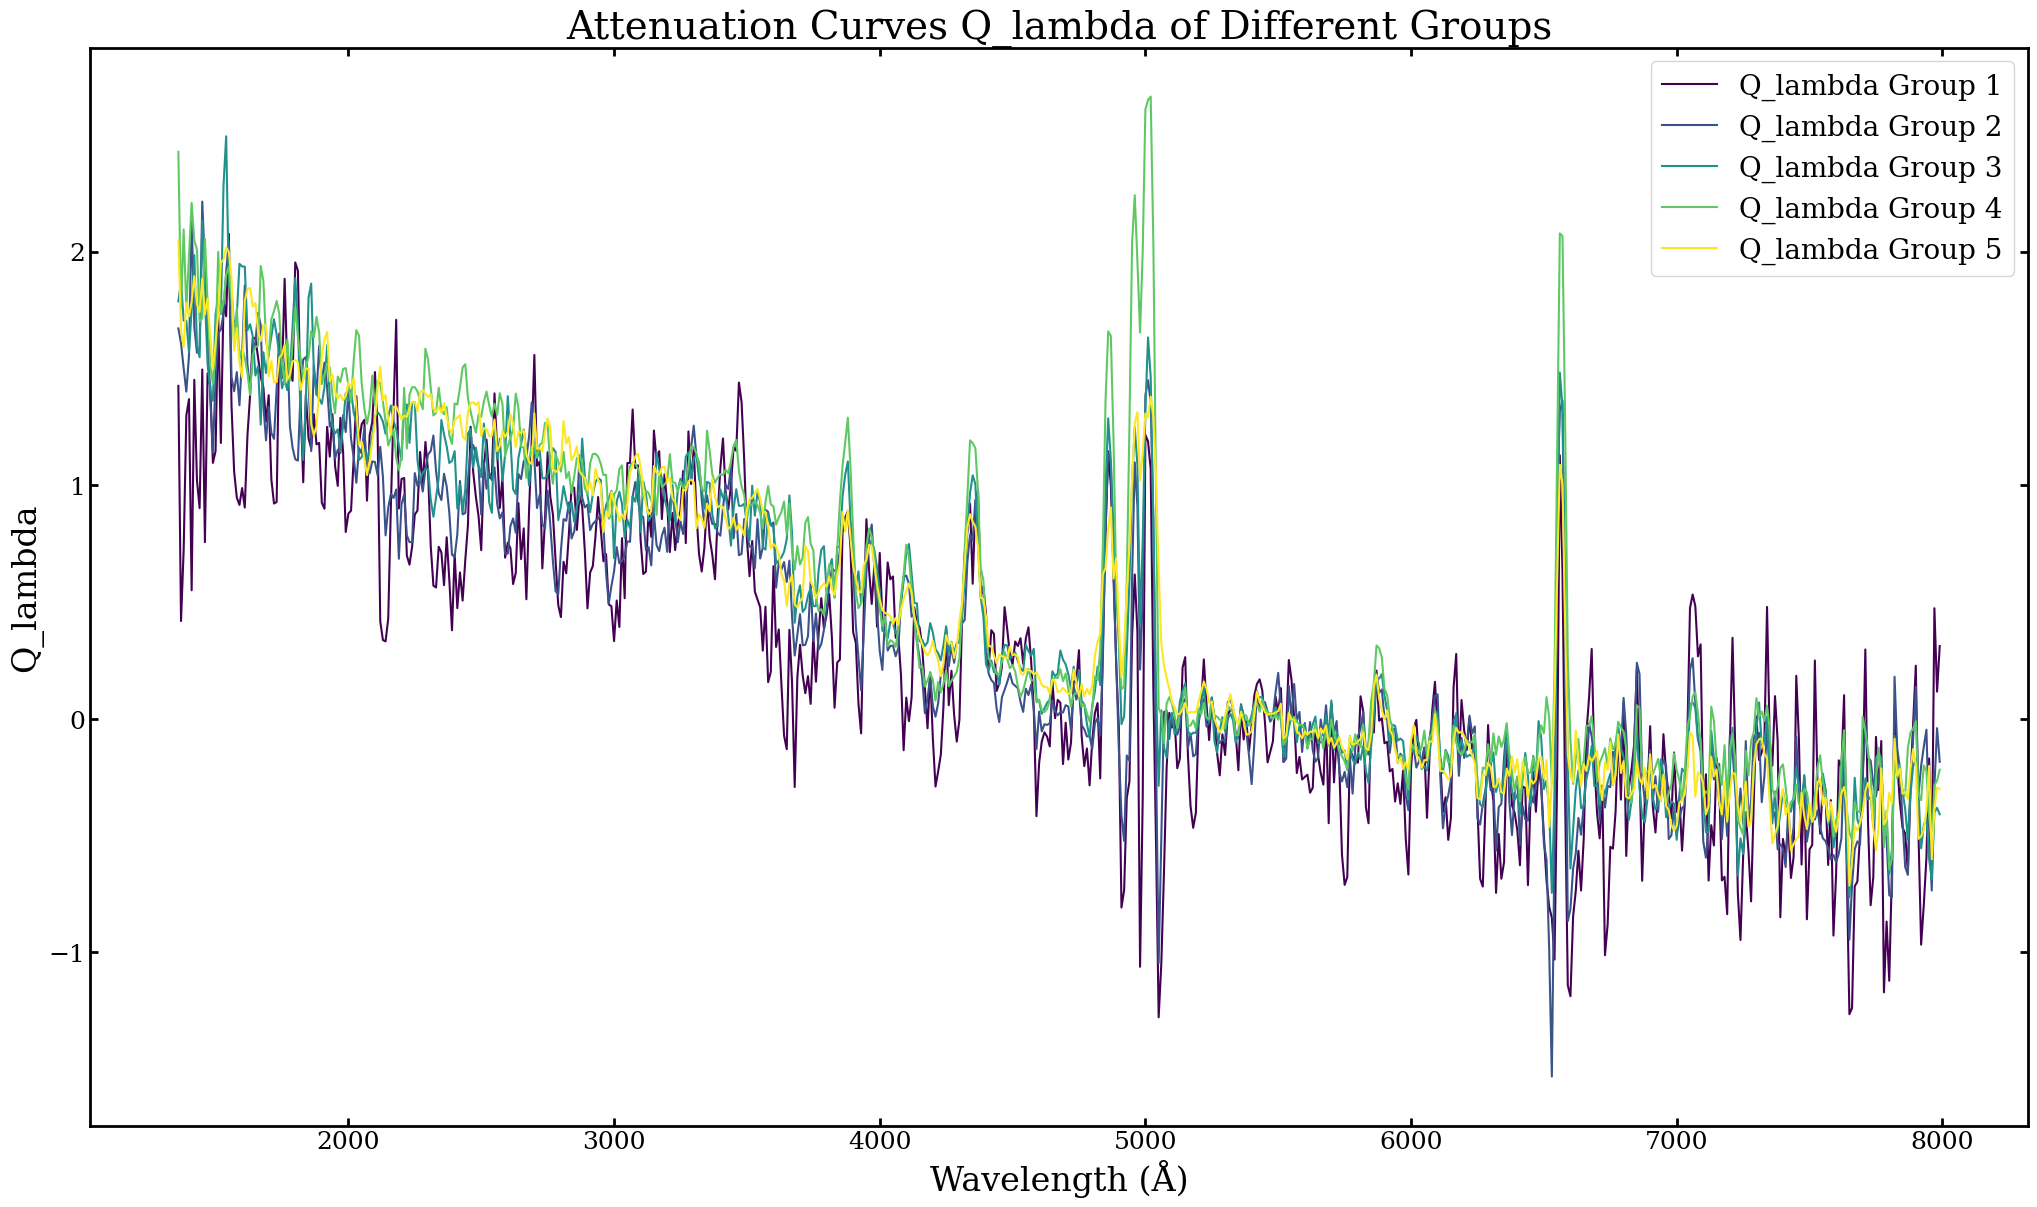

In [10]:
fig, ax=plt.subplots(figsize=(25,14))
colors=plt.cm.viridis(np.linspace(0,1,5))
for i in range(5):
    Q_lambda=Q_lambda_list[i]
    averager_to_use='group'+str(i+1)+'_averager'
    averager=globals()[averager_to_use]
    ax.plot(averager.common_wavelength, Q_lambda, color=colors[i], label='Q_lambda Group '+str(i+1))
ax.set_xlabel('Wavelength (Å)', fontsize=24)
ax.set_ylabel('Q_lambda', fontsize=24)
ax.legend(fontsize=20)

ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18)
ax.yaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18)
ax.xaxis.set_tick_params(length=6, which='major')
ax.xaxis.set_tick_params(length=3, which='minor')
ax.yaxis.set_tick_params(length=6, which='major')
ax.yaxis.set_tick_params(length=3, which='minor')
ax.set_title('Attenuation Curves Q_lambda of Different Groups', fontsize=28)
plt.savefig('Attenuation_Curves_Q_lambda_of_Different_Groups_Region.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
def Calzetti(input_lambda):
    x=1/input_lambda
    Q=-2.156+1.509*x-0.198*x**2+0.011*x**3
    return Q

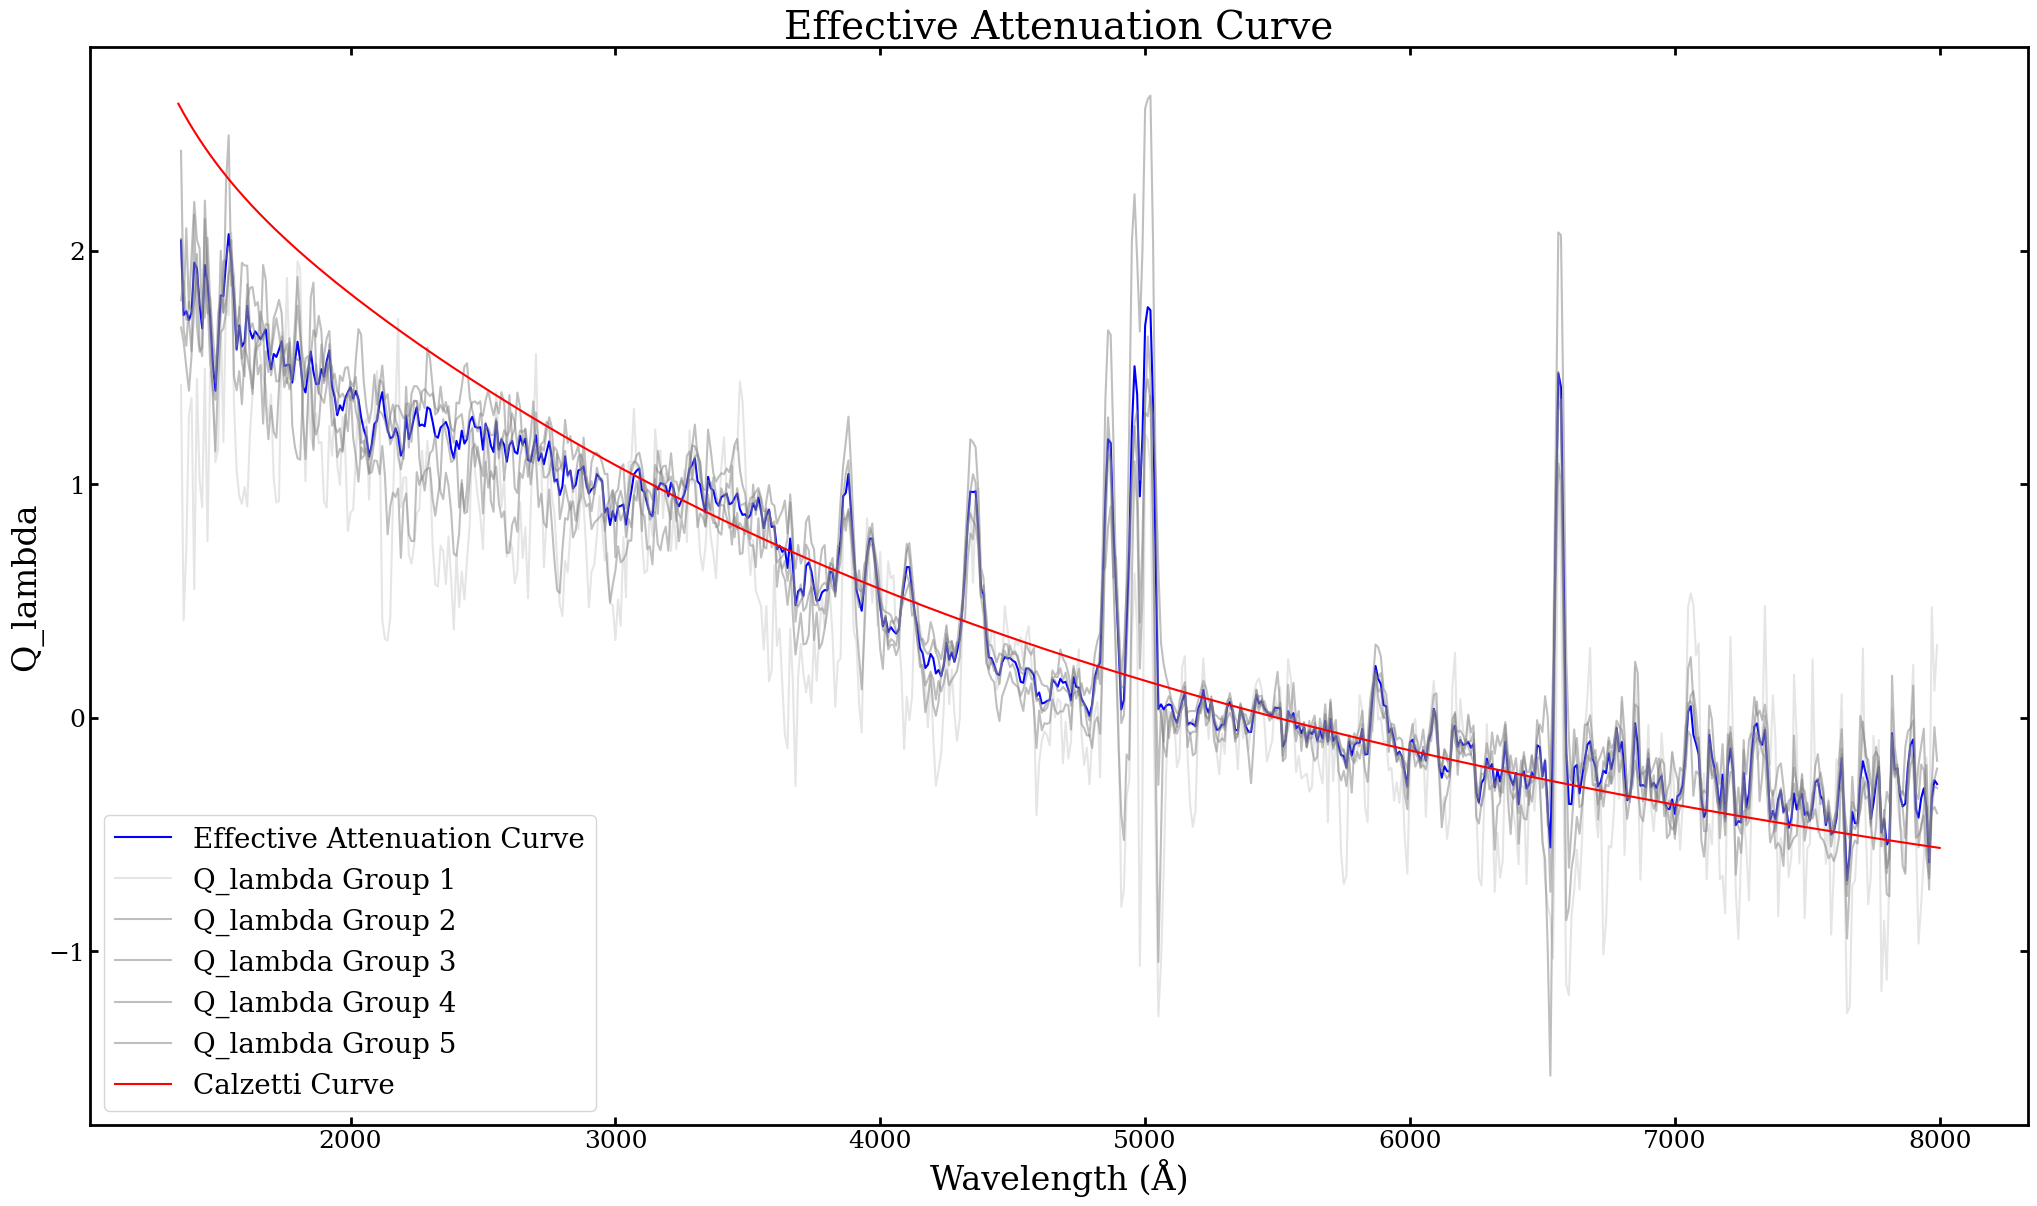

In [12]:
Q_lambda_array=np.array(Q_lambda_list)


effective_attenuation_curve=np.average(Q_lambda_array[1:], axis=0, weights=[group_decrement_list[2]-group_decrement_list[0], group_decrement_list[3]-group_decrement_list[0], group_decrement_list[4]-group_decrement_list[0], group_decrement_list[5]-group_decrement_list[0]])
fig, ax=plt.subplots(figsize=(25,14))
averager=group1_averager
ax.plot(averager.common_wavelength, effective_attenuation_curve, color='blue', label='Effective Attenuation Curve')
for i in range(0,5):
    Q_lambda=Q_lambda_list[i]
    averager_to_use='group'+str(i+1)+'_averager'
    averager=globals()[averager_to_use]
    ax.plot(averager.common_wavelength, Q_lambda, color='gray', alpha=0.5 if i!=0 else 0.2, label='Q_lambda Group '+str(i+1))

calzetti_curve=Calzetti((averager.common_wavelength*u.AA).to(u.micron).value)
ax.plot(averager.common_wavelength, calzetti_curve, color='red', label='Calzetti Curve')
plt.xlabel('Wavelength (Å)', fontsize=24)
plt.ylabel('Q_lambda', fontsize=24)
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18)
ax.yaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18)
ax.xaxis.set_tick_params(length=6, which='major')
ax.xaxis.set_tick_params(length=3, which='minor')
ax.yaxis.set_tick_params(length=6, which='major')
ax.yaxis.set_tick_params(length=3, which='minor')
ax.set_title('Effective Attenuation Curve', fontsize=28)
plt.legend(fontsize=20)
plt.savefig('Effective_Attenuation_Curve_vs_Calzetti_Curve_Region.pdf', bbox_inches='tight', dpi=300)
plt.show()

---
Compare with Calzetti

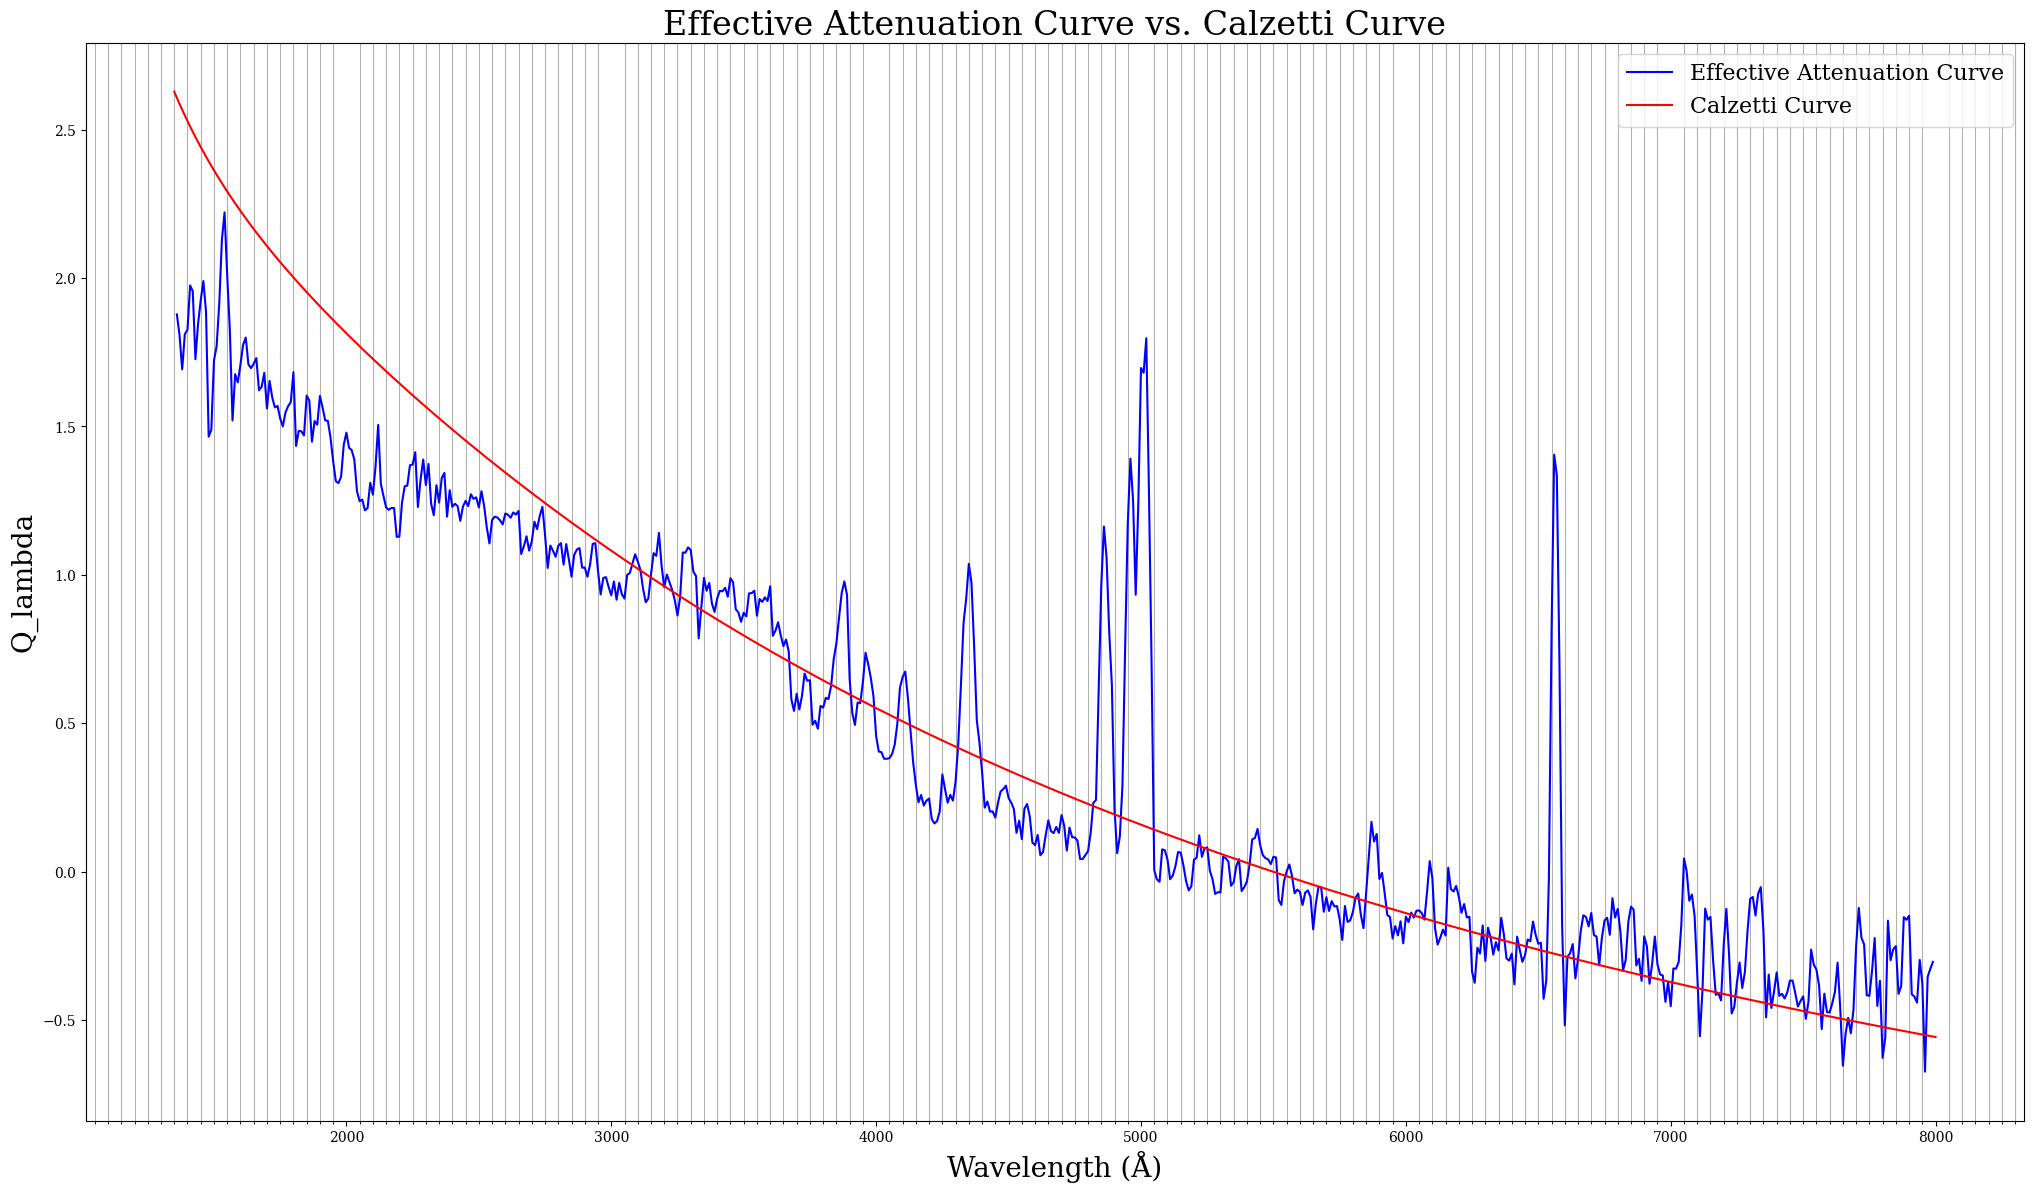

In [54]:
def Calzetti(input_lambda):
    x=1/input_lambda
    Q=-2.156+1.509*x-0.198*x**2+0.011*x**3
    return Q

calzetti_curve=Calzetti((averager.common_wavelength*u.AA).to(u.micron).value)
fig, ax=plt.subplots(figsize=(25,14))
averager=group1_averager
ax.plot(averager.common_wavelength, effective_attenuation_curve, color='blue', label='Effective Attenuation Curve')
ax.plot(averager.common_wavelength, calzetti_curve, color='red', label='Calzetti Curve')
plt.xlabel('Wavelength (Å)', fontsize=20)
plt.ylabel('Q_lambda', fontsize=20)
plt.title('Effective Attenuation Curve vs. Calzetti Curve', fontsize=24)
plt.legend(fontsize=16)
# show a more detailed grid
ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(50))
ax.grid(True, which='minor', axis='x')

---
# in the following section. i will derive the attenuation curve from the average spectrum.

In [13]:
from scipy.optimize import curve_fit
wave = np.array(averager.common_wavelength)  # 单位: Angstrom
Q_curve = np.array(effective_attenuation_curve)


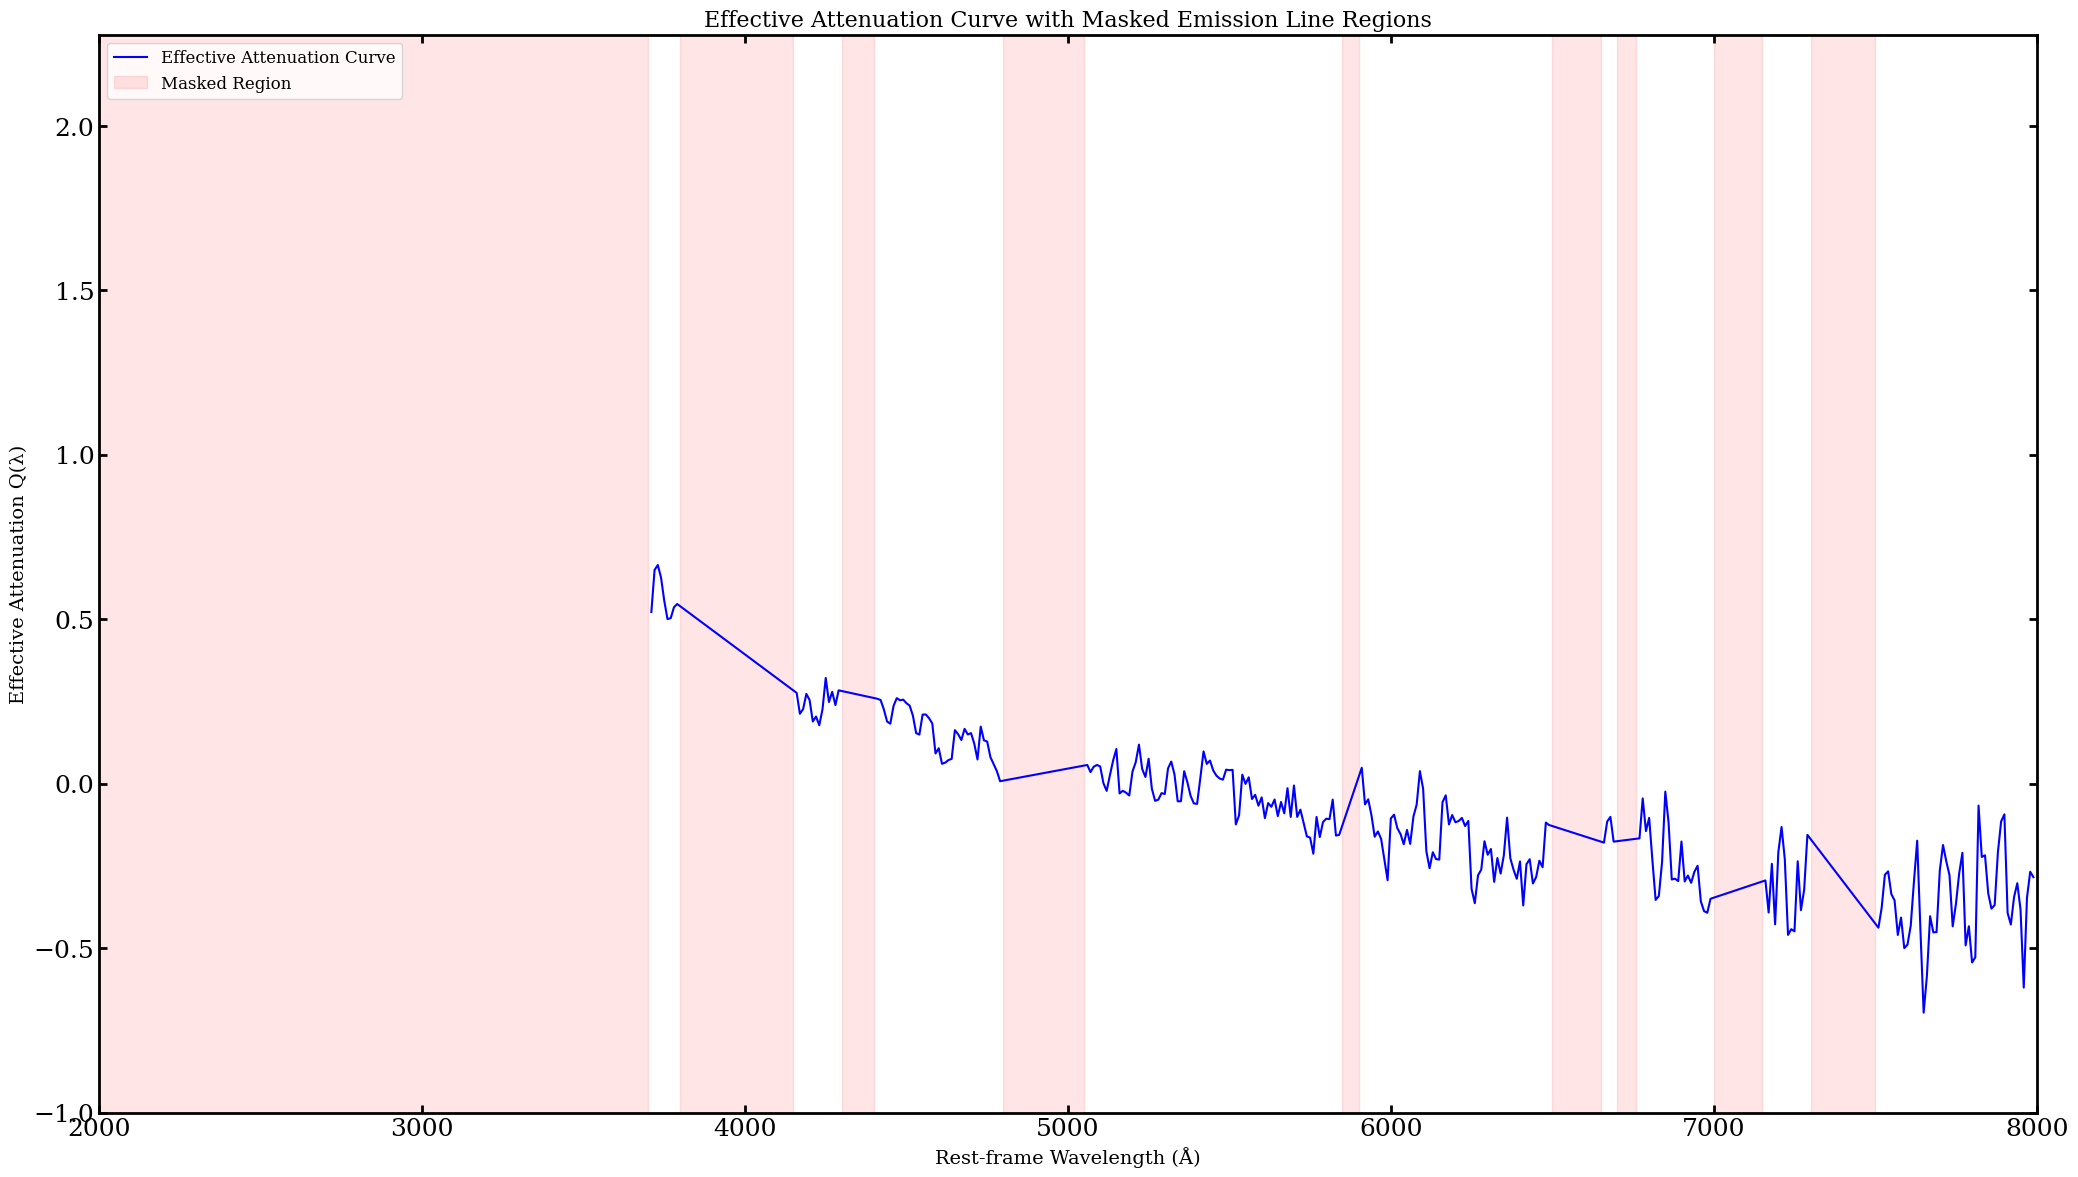

In [14]:

mask_regions = [
    (800,3700),
    (3800,4150),
    (4300, 4400),  # Ca II H+K
    (4800, 5050),  # H-beta (4861) + [OIII] (4959, 5007) - 这是一个大包络
    (5850,5900),
    (6500, 6650),  # H-alpha (6563) + [NII]
    (6700, 6760) ,  # [SII] Doublet
    (7000,7150),
    (7300,7500)
]

is_continuum = np.ones_like(wave, dtype=bool)
for start, end in mask_regions:
    is_continuum &= ~((wave >= start) & (wave <= end))
fig, ax = plt.subplots(figsize=(25,14))
ax.plot(wave[is_continuum], Q_curve[is_continuum], label='Effective Attenuation Curve', color='blue')
for start, end in mask_regions:
    ax.axvspan(start, end, color='red', alpha=0.1, label='Masked Region' if start==mask_regions[0][0] else "")
ax.set_xlabel('Rest-frame Wavelength (Å)', fontsize=14)
ax.set_ylabel('Effective Attenuation Q(λ)', fontsize=14)
ax.set_title('Effective Attenuation Curve with Masked Emission Line Regions', fontsize=16)
ax.legend(fontsize=12)
ax.set_xlim(2000, 8000)
ax.set_ylim(-1, np.nanmax(Q_curve)*1.1)
plt.show()

Zero-point Shift C: -1.0849
------------------------------
Value at B (from fit, unscaled): 1.2933
Value at V (from fit, unscaled): 1.0451
Scaling Factor: 4.0288
------------------------------
Measured R_V (z=3-7): 4.2104
------------------------------


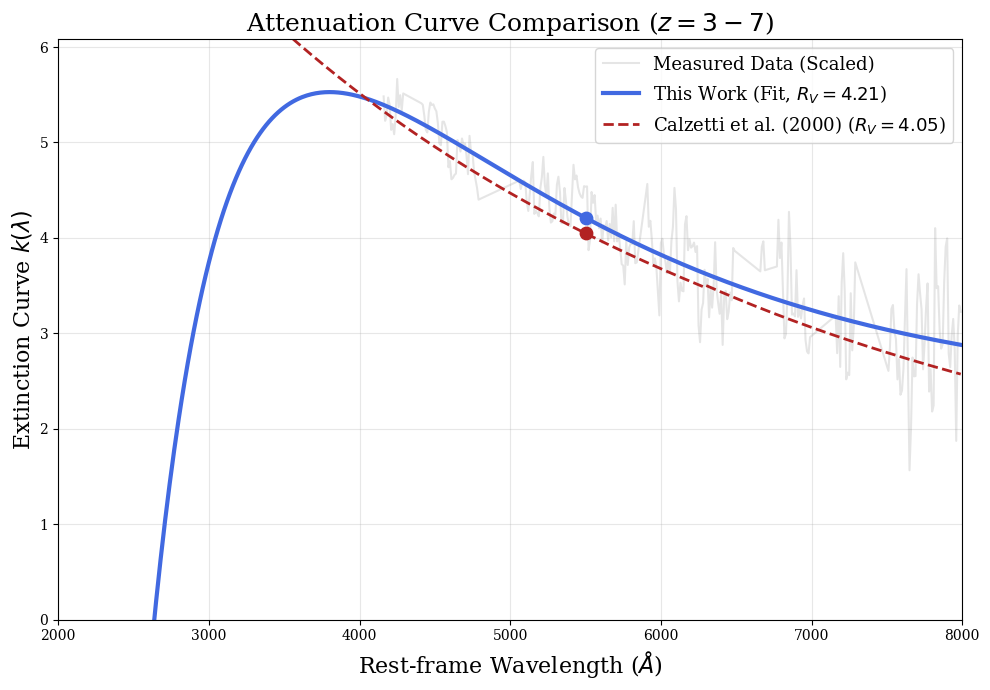


=== Final Curve Polynomial Coefficients ===
Formula: k(lambda) = a + b/x + c/x^2 + d/x^3  (x = lambda in microns)
a = 5.1298
b = -7.0784
c = 5.5546
d = -1.0668

Derived R_V = k(0.55um) = 4.2104


In [87]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ==========================================
# 1. 准备数据 & Mask
# ==========================================
wave = np.array(averager.common_wavelength)  # Angstrom
Q_curve = np.array(effective_attenuation_curve)

# 定义强发射线区域 (会被排除在计算之外)
mask_regions = [
    (800,4100),
    (3800,4150),
    (4300, 4400),  # Ca II H+K
    (4800, 5050),  # H-beta (4861) + [OIII] (4959, 5007) - 这是一个大包络
    (5850,5900),
    (6500, 6650),  # H-alpha (6563) + [NII]
    (6700, 6760) ,  # [SII] Doublet
    (7000,7150),
    (7300,7500)
]

is_continuum = np.ones_like(wave, dtype=bool)
for start, end in mask_regions:
    is_continuum &= ~((wave >= start) & (wave <= end))

# 排除数据中的 NaN 和 Inf
valid_data = np.isfinite(Q_curve) & np.isfinite(wave)
is_continuum &= valid_data

# ==========================================
# 2. 长波平移 (Zero-Point Shift)
# ==========================================
# 使用 1/lambda 拟合 6000-8000A 的连续谱，使其趋于 0# ==========================================
# 2. 长波平移 (Zero-Point Shift)
# ==========================================
mask_tail = (wave > 6000) & (wave < 8000) & is_continuum
def tail_func(lam, A, C):
    return A * (lam/5500)**(-1) + C

if np.sum(mask_tail) > 10:
    popt_tail, _ = curve_fit(tail_func, wave[mask_tail], Q_curve[mask_tail])
    C_shift = popt_tail[1]
else:
    C_shift = 0.0

Q_shifted = Q_curve - C_shift
print(f"Zero-point Shift C: {C_shift:.4f}")

# ==========================================
# 3. 多项式拟合 (先拟合，再归一化)
# ==========================================

# 定义多项式模型 (x = 1/lambda_micron)
def poly_model(lam_micron, a, b, c, d):
    x = 1.0 / lam_micron
    return a + b*x + c*(x**2) + d*(x**3)

# 准备拟合数据 (单位转换: Angstrom -> Micron)
microns = wave / 10000.0
fit_mask = (wave > 1250) & (wave < 8000) & is_continuum # 拟合范围

# 对 Q_shifted (未归一化) 进行拟合
popt_Q, _ = curve_fit(poly_model, microns[fit_mask], Q_shifted[fit_mask])

# 生成光滑的 Q 拟合曲线
Q_smooth = poly_model(microns, *popt_Q)

# ==========================================
# 4. 计算归一化因子 & Rv
# ==========================================
# 直接从光滑拟合曲线上取值，消除噪点影响
val_B_smooth = poly_model(0.4400, *popt_Q) # 4400A = 0.44um
val_V_smooth = poly_model(0.5500, *popt_Q) # 5500A = 0.55um

# 计算缩放因子 S
scaling_factor = 1.0 / (val_B_smooth - val_V_smooth)

# 计算最终的 k 曲线和 Rv
k_fit = Q_smooth * scaling_factor
k_data_scaled = Q_shifted * scaling_factor # 原始数据也乘同样的因子，用于画背景

# Rv 就是归一化后的曲线在 V 波段的值
Rv_measured = val_V_smooth * scaling_factor

print("-" * 30)
print(f"Value at B (from fit, unscaled): {val_B_smooth:.4f}")
print(f"Value at V (from fit, unscaled): {val_V_smooth:.4f}")
print(f"Scaling Factor: {scaling_factor:.4f}")
print("-" * 30)
print(f"Measured R_V (z=3-7): {Rv_measured:.4f}")
print("-" * 30)

# ==========================================
# 5. 生成 Calzetti 对比曲线
# ==========================================
def calzetti_2000_law(lam_angstroms, Rv=4.05):
    lam_um = lam_angstroms / 10000.0
    k = np.zeros_like(lam_um)
    mask1 = (lam_um >= 0.12) & (lam_um < 0.63)
    x = lam_um[mask1]
    k[mask1] = 2.659 * (-2.156 + 1.509/x - 0.198/x**2 + 0.011/x**3) + Rv
    mask2 = (lam_um >= 0.63) & (lam_um <= 2.2)
    x = lam_um[mask2]
    k[mask2] = 2.659 * (-1.857 + 1.040/x) + Rv
    return k

k_standard = calzetti_2000_law(wave)

# ==========================================
# 6. 画图
# ==========================================
fig, ax = plt.subplots(figsize=(10, 7))

# 1. 原始数据 (归一化后的) - 作为背景
ax.plot(wave[is_continuum], k_data_scaled[is_continuum], color='gray', alpha=0.2, label='Measured Data (Scaled)')

# 2. 你的拟合结果 (k_fit)
plot_range = (wave > 1300) & (wave < 8000)
ax.plot(wave[plot_range], k_fit[plot_range], color='royalblue', linewidth=3,
        label=f'This Work (Fit, $R_V={Rv_measured:.2f}$)')

# 3. Calzetti 标准曲线
ax.plot(wave[plot_range], k_standard[plot_range], color='firebrick', linestyle='--', linewidth=2,
        label='Calzetti et al. (2000) ($R_V=4.05$)')

# 标注 Rv
v_wave = 5500
ax.scatter([v_wave], [Rv_measured], s=80, color='royalblue', zorder=10)
ax.scatter([v_wave], [4.05], s=80, color='firebrick', zorder=10)

# 装饰
ax.set_xlabel(r'Rest-frame Wavelength ($\AA$)', fontsize=16)
ax.set_ylabel(r'Extinction Curve $k(\lambda)$', fontsize=16)
ax.set_title(r'Attenuation Curve Comparison ($z=3-7$)', fontsize=18)
ax.legend(fontsize=13)
ax.grid(True, alpha=0.3)
ax.set_xlim(2000, 8000)
# 限制Y轴，防止紫外端发散影响显示
y_max = np.max(k_fit[(wave>2000)&(wave<8000)]) * 1.1
ax.set_ylim(0, y_max)

plt.tight_layout()
plt.show()

# ==========================================
# 7. 输出最终公式系数
# ==========================================
# k_fit = Q_smooth * S
# Q_smooth = a + b/x + ...
# 所以 k_fit 的系数就是原来的系数 * S
final_coeffs = popt_Q * scaling_factor

print("\n=== Final Curve Polynomial Coefficients ===")
print("Formula: k(lambda) = a + b/x + c/x^2 + d/x^3  (x = lambda in microns)")
print(f"a = {final_coeffs[0]:.4f}")
print(f"b = {final_coeffs[1]:.4f}")
print(f"c = {final_coeffs[2]:.4f}")
print(f"d = {final_coeffs[3]:.4f}")
print(f"\nDerived R_V = k(0.55um) = {Rv_measured:.4f}")

拟合得到的 d 系数: 0.00000
------------------------------
Scaling Factor: 3.9665
Measured R_V (z=3-7): 4.1337
------------------------------


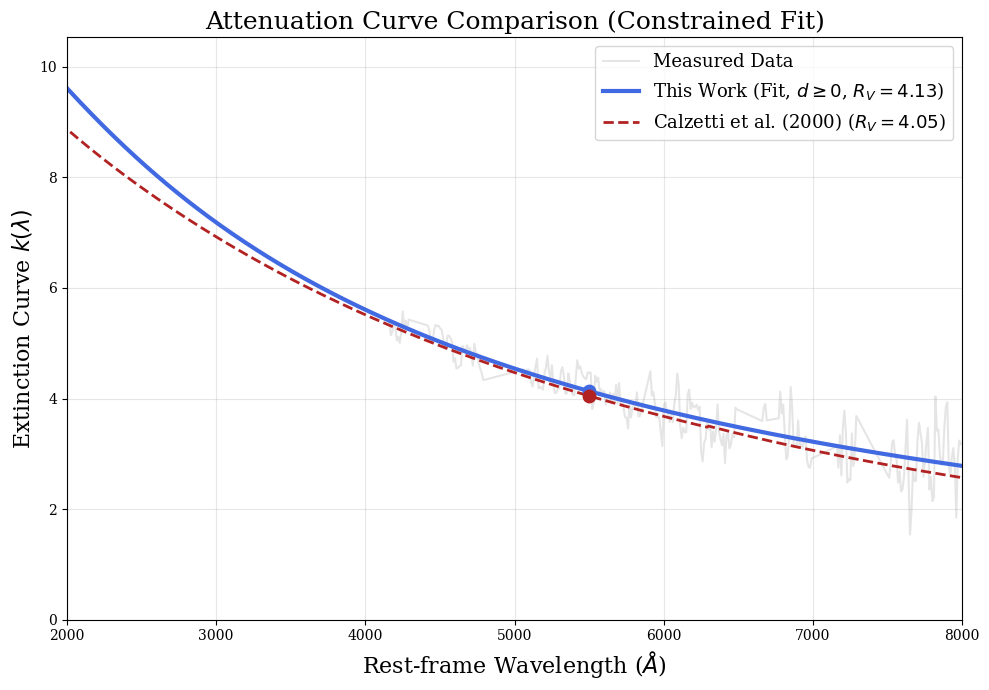


=== Final Constrained Polynomial Coefficients ===
Formula: k(lambda) = a + b/x + c/x^2 + d/x^3  (x = lambda in microns)
a = -0.5904
b = 2.9169
c = -0.1752
d = 0.0000 (Constraint: d >= 0)

Derived R_V = 4.1337


In [88]:
mask_tail = (wave > 6000) & (wave < 8000) & is_continuum
def tail_func(lam, A, C):
    return A * (lam/5500)**(-1) + C

if np.sum(mask_tail) > 10:
    popt_tail, _ = curve_fit(tail_func, wave[mask_tail], Q_curve[mask_tail])
    C_shift = popt_tail[1]
else:
    C_shift = 0.0

Q_shifted = Q_curve - C_shift

# ==========================================
# 3. 约束拟合 (Constrained Fitting)
# ==========================================

# 定义多项式模型 (x = 1/lambda_micron)
def poly_model(lam_micron, a, b, c, d):
    x = 1.0 / lam_micron
    return a + b*x + c*(x**2) + d*(x**3)

microns = wave / 10000.0
fit_mask = (wave > 1250) & (wave < 8000) & is_continuum

# --- 关键修改：添加 bounds 参数 ---
# 参数顺序: a, b, c, d
# 下限: a,b,c 无限制 (-inf), d >= 0
# 上限: 全部无限制 (+inf)
lower_bounds = [-np.inf, -np.inf, -np.inf, 0.0]
upper_bounds = [np.inf, np.inf, np.inf, np.inf]

# 建议提供一个满足约束的初始猜测 (p0)，有助于收敛
p0_guess = [0, 0, 0, 0.1]

popt_Q, pcov_Q = curve_fit(
    poly_model,
    microns[fit_mask],
    Q_shifted[fit_mask],
    p0=p0_guess,
    bounds=(lower_bounds, upper_bounds) # <--- 强制 d >= 0
)

# 生成光滑的 Q 拟合曲线
Q_smooth = poly_model(microns, *popt_Q)

# 检查 d 是否真的非负
print(f"拟合得到的 d 系数: {popt_Q[3]:.5f}")

# ==========================================
# 4. 计算归一化因子 & Rv
# ==========================================
# 从光滑拟合曲线上取值
val_B_smooth = poly_model(0.4400, *popt_Q)
val_V_smooth = poly_model(0.5500, *popt_Q)

# 计算缩放因子 S
scaling_factor = 1.0 / (val_B_smooth - val_V_smooth)

# 计算最终的 k 曲线
k_fit = Q_smooth * scaling_factor
k_data_scaled = Q_shifted * scaling_factor

# Rv 就是归一化后的曲线在 V 波段的值
Rv_measured = val_V_smooth * scaling_factor

print("-" * 30)
print(f"Scaling Factor: {scaling_factor:.4f}")
print(f"Measured R_V (z=3-7): {Rv_measured:.4f}")
print("-" * 30)

# ==========================================
# 5. 生成 Calzetti 对比曲线 (略微简化代码)
# ==========================================
def calzetti_2000_law(lam_angstroms, Rv=4.05):
    lam_um = lam_angstroms / 10000.0
    k = np.zeros_like(lam_um)
    mask1 = (lam_um >= 0.12) & (lam_um < 0.63)
    x = lam_um[mask1]
    k[mask1] = 2.659 * (-2.156 + 1.509/x - 0.198/x**2 + 0.011/x**3) + Rv
    mask2 = (lam_um >= 0.63) & (lam_um <= 2.2)
    x = lam_um[mask2]
    k[mask2] = 2.659 * (-1.857 + 1.040/x) + Rv
    return k

k_standard = calzetti_2000_law(wave)

# ==========================================
# 6. 画图
# ==========================================
fig, ax = plt.subplots(figsize=(10, 7))

# 背景数据
ax.plot(wave[fit_mask], k_data_scaled[fit_mask], color='gray', alpha=0.2, label='Measured Data')

# 你的拟合 (约束 d>0)
plot_range = (wave > 1300) & (wave < 8000)
ax.plot(wave[plot_range], k_fit[plot_range], color='royalblue', linewidth=3,
        label=f'This Work (Fit, $d \geq 0$, $R_V={Rv_measured:.2f}$)')

# Calzetti
ax.plot(wave[plot_range], k_standard[plot_range], color='firebrick', linestyle='--', linewidth=2,
        label='Calzetti et al. (2000) ($R_V=4.05$)')

# 标注 Rv
v_wave = 5500
ax.scatter([v_wave], [Rv_measured], s=80, color='royalblue', zorder=10)
ax.scatter([v_wave], [4.05], s=80, color='firebrick', zorder=10)

ax.set_xlabel(r'Rest-frame Wavelength ($\AA$)', fontsize=16)
ax.set_ylabel(r'Extinction Curve $k(\lambda)$', fontsize=16)
ax.set_title(r'Attenuation Curve Comparison (Constrained Fit)', fontsize=18)
ax.legend(fontsize=13)
ax.grid(True, alpha=0.3)
ax.set_xlim(2000, 8000)
y_max = np.max(k_fit[(wave>2000)&(wave<8000)]) * 1.1
ax.set_ylim(0, y_max)

plt.tight_layout()
plt.show()

# ==========================================
# 7. 输出最终公式系数
# ==========================================
final_coeffs = popt_Q * scaling_factor

print("\n=== Final Constrained Polynomial Coefficients ===")
print("Formula: k(lambda) = a + b/x + c/x^2 + d/x^3  (x = lambda in microns)")
print(f"a = {final_coeffs[0]:.4f}")
print(f"b = {final_coeffs[1]:.4f}")
print(f"c = {final_coeffs[2]:.4f}")
print(f"d = {final_coeffs[3]:.4f} (Constraint: d >= 0)")
print(f"\nDerived R_V = {Rv_measured:.4f}")

Zero-point Shift C: -1.0849
------------------------------
Value at B (from fit, unscaled): 1.4342
Value at V (from fit, unscaled): 1.1042
Scaling Factor: 3.0306
------------------------------
Measured R_V (z=3-7): 3.3464
------------------------------


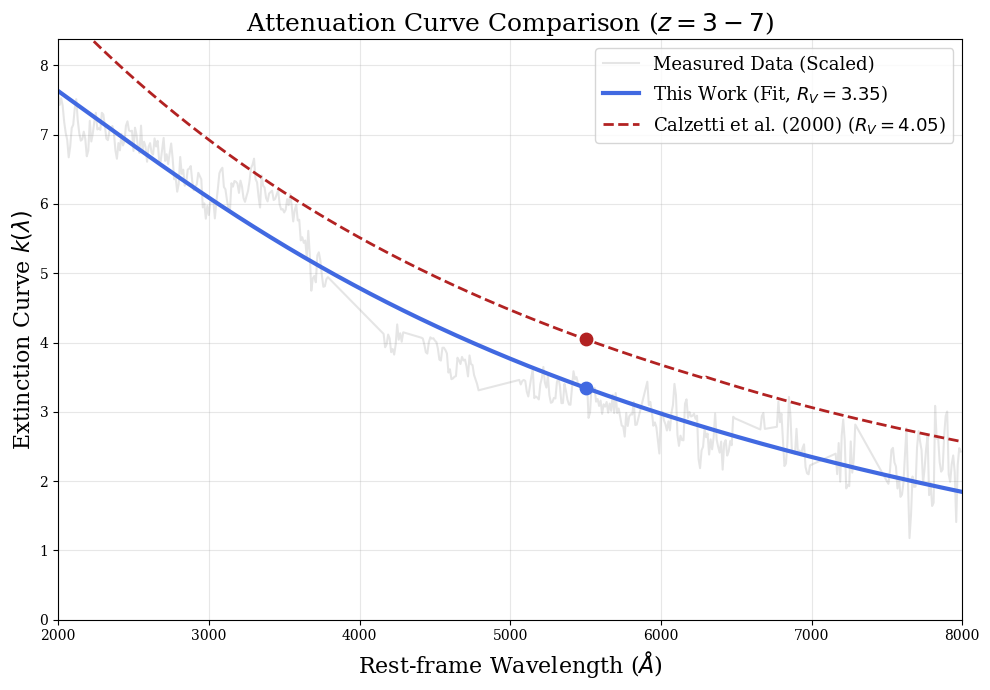


=== Final Curve Polynomial Coefficients ===
Formula: k(lambda) = a + b/x + c/x^2 + d/x^3  (x = lambda in microns)
a = -2.6114
b = 4.2711
c = -0.6053
d = 0.0321

Derived R_V = k(0.55um) = 3.3464


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ==========================================
# 1. 准备数据 & Mask
# ==========================================
wave = np.array(averager.common_wavelength)  # Angstrom
Q_curve = np.array(effective_attenuation_curve)

# 定义强发射线区域 (会被排除在计算之外)
mask_regions = [

    (3800,4150),
    (4300, 4400),  # Ca II H+K
    (4800, 5050),  # H-beta (4861) + [OIII] (4959, 5007) - 这是一个大包络
    (5850,5900),
    (6500, 6650),  # H-alpha (6563) + [NII]
    (6700, 6760) ,  # [SII] Doublet
    (7000,7150),
    (7300,7500)
]

is_continuum = np.ones_like(wave, dtype=bool)
for start, end in mask_regions:
    is_continuum &= ~((wave >= start) & (wave <= end))

# 排除数据中的 NaN 和 Inf
valid_data = np.isfinite(Q_curve) & np.isfinite(wave)
is_continuum &= valid_data
# ==========================================
# 2. 长波平移 (Zero-Point Shift)
# ==========================================
mask_tail = (wave > 6000) & (wave < 8000) & is_continuum
def tail_func(lam, A, C):
    return A * (lam/5500)**(-1) + C

if np.sum(mask_tail) > 10:
    popt_tail, _ = curve_fit(tail_func, wave[mask_tail], Q_curve[mask_tail])
    C_shift = popt_tail[1]
else:
    C_shift = 0.0

Q_shifted = Q_curve - C_shift
print(f"Zero-point Shift C: {C_shift:.4f}")

# ==========================================
# 3. 多项式拟合 (先拟合，再归一化)
# ==========================================

# 定义多项式模型 (x = 1/lambda_micron)
def poly_model(lam_micron, a, b, c, d):
    x = 1.0 / lam_micron
    return a + b*x + c*(x**2) + d*(x**3)

# 准备拟合数据 (单位转换: Angstrom -> Micron)
microns = wave / 10000.0
fit_mask = (wave > 1250) & (wave < 8000) & is_continuum # 拟合范围

# 对 Q_shifted (未归一化) 进行拟合
popt_Q, _ = curve_fit(poly_model, microns[fit_mask], Q_shifted[fit_mask])

# 生成光滑的 Q 拟合曲线
Q_smooth = poly_model(microns, *popt_Q)

# ==========================================
# 4. 计算归一化因子 & Rv
# ==========================================
# 直接从光滑拟合曲线上取值，消除噪点影响
val_B_smooth = poly_model(0.4400, *popt_Q) # 4400A = 0.44um
val_V_smooth = poly_model(0.5500, *popt_Q) # 5500A = 0.55um

# 计算缩放因子 S
scaling_factor = 1.0 / (val_B_smooth - val_V_smooth)

# 计算最终的 k 曲线和 Rv
k_fit = Q_smooth * scaling_factor
k_data_scaled = Q_shifted * scaling_factor # 原始数据也乘同样的因子，用于画背景

# Rv 就是归一化后的曲线在 V 波段的值
Rv_measured = val_V_smooth * scaling_factor

print("-" * 30)
print(f"Value at B (from fit, unscaled): {val_B_smooth:.4f}")
print(f"Value at V (from fit, unscaled): {val_V_smooth:.4f}")
print(f"Scaling Factor: {scaling_factor:.4f}")
print("-" * 30)
print(f"Measured R_V (z=3-7): {Rv_measured:.4f}")
print("-" * 30)

# ==========================================
# 5. 生成 Calzetti 对比曲线
# ==========================================
def calzetti_2000_law(lam_angstroms, Rv=4.05):
    lam_um = lam_angstroms / 10000.0
    k = np.zeros_like(lam_um)
    mask1 = (lam_um >= 0.12) & (lam_um < 0.63)
    x = lam_um[mask1]
    k[mask1] = 2.659 * (-2.156 + 1.509/x - 0.198/x**2 + 0.011/x**3) + Rv
    mask2 = (lam_um >= 0.63) & (lam_um <= 2.2)
    x = lam_um[mask2]
    k[mask2] = 2.659 * (-1.857 + 1.040/x) + Rv
    return k

k_standard = calzetti_2000_law(wave)

# ==========================================
# 6. 画图
# ==========================================
fig, ax = plt.subplots(figsize=(10, 7))

# 1. 原始数据 (归一化后的) - 作为背景
ax.plot(wave[is_continuum], k_data_scaled[is_continuum], color='gray', alpha=0.2, label='Measured Data (Scaled)')

# 2. 你的拟合结果 (k_fit)
plot_range = (wave > 1300) & (wave < 8000)
ax.plot(wave[plot_range], k_fit[plot_range], color='royalblue', linewidth=3,
        label=f'This Work (Fit, $R_V={Rv_measured:.2f}$)')

# 3. Calzetti 标准曲线
ax.plot(wave[plot_range], k_standard[plot_range], color='firebrick', linestyle='--', linewidth=2,
        label='Calzetti et al. (2000) ($R_V=4.05$)')

# 标注 Rv
v_wave = 5500
ax.scatter([v_wave], [Rv_measured], s=80, color='royalblue', zorder=10)
ax.scatter([v_wave], [4.05], s=80, color='firebrick', zorder=10)

# 装饰
ax.set_xlabel(r'Rest-frame Wavelength ($\AA$)', fontsize=16)
ax.set_ylabel(r'Extinction Curve $k(\lambda)$', fontsize=16)
ax.set_title(r'Attenuation Curve Comparison ($z=3-7$)', fontsize=18)
ax.legend(fontsize=13)
ax.grid(True, alpha=0.3)
ax.set_xlim(2000, 8000)
# 限制Y轴，防止紫外端发散影响显示
y_max = np.max(k_fit[(wave>2000)&(wave<8000)]) * 1.1
ax.set_ylim(0, y_max)

plt.tight_layout()
plt.show()

# ==========================================
# 7. 输出最终公式系数
# ==========================================
# k_fit = Q_smooth * S
# Q_smooth = a + b/x + ...
# 所以 k_fit 的系数就是原来的系数 * S
final_coeffs = popt_Q * scaling_factor

print("\n=== Final Curve Polynomial Coefficients ===")
print("Formula: k(lambda) = a + b/x + c/x^2 + d/x^3  (x = lambda in microns)")
print(f"a = {final_coeffs[0]:.4f}")
print(f"b = {final_coeffs[1]:.4f}")
print(f"c = {final_coeffs[2]:.4f}")
print(f"d = {final_coeffs[3]:.4f}")
print(f"\nDerived R_V = k(0.55um) = {Rv_measured:.4f}")

=== Polynomial Fit Parameters (Raw) ===
a (Intercept at 1/lam=0) = -1.9466
b = 1.4094
c = -0.1997
d = 0.0106

[Strategy] Force A(inf) = 0
Zero-point Shift applied: -1.9466
------------------------------
A(V) [ln scale] = 1.9659
E(B-V) [ln scale] = 0.3300
------------------------------
Measured R_V = 5.9579
------------------------------


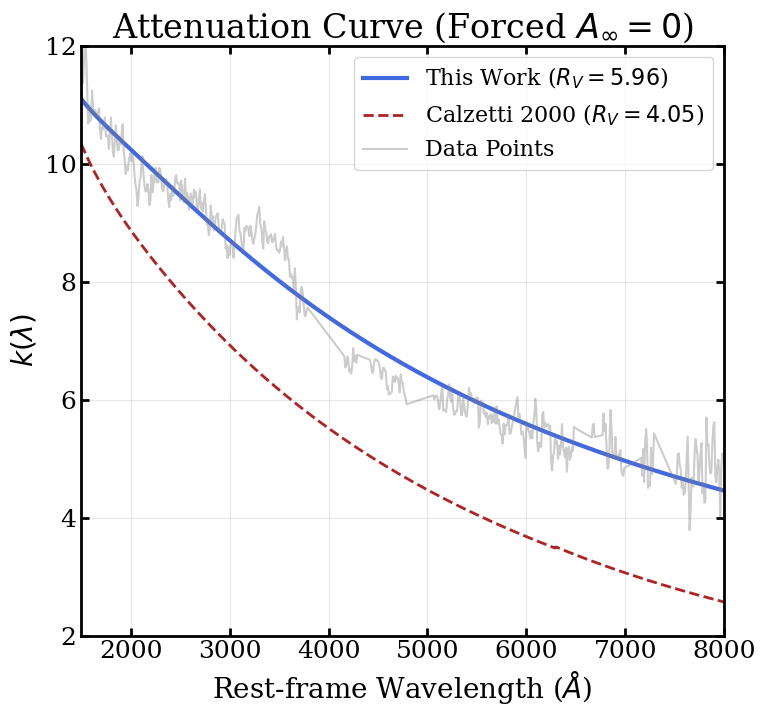


=== Final k(lambda) Formula Coefficients ===
k(lambda) = b*(1/x) + c*(1/x)^2 + d*(1/x)^3  [x in microns]
b = 4.2711
c = -0.6053
d = 0.0321

     DERIVING FINAL NORMALIZED FORMULA
Your Scaling Factor (comparable to 2.659): 3.0306

[Form 1] Standard Polynomial Form:
k(lambda) = b*(1/lam) + c*(1/lam)^2 + d*(1/lam)^3
Where lam is in microns.
------------------------------
b = 4.2711
c = -0.6053
d = 0.0321
------------------------------
Derived R_V = 5.9579

[Form 2] Calzetti-Style (Separated Rv):
k(lambda) = D + 4.271*(1/lam) -0.605*(1/lam)^2 +0.032*(1/lam)^3 + R_V
Fixed Constant D = -5.9579
Measured R_V = 5.9579
Validation Check at V-band (Should be 5.9579): 5.9579


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ==========================================
# 假设变量 (请确保这些数据已加载)
# ==========================================
wave = np.array(averager.common_wavelength)  # Angstrom
Q_curve = np.array(effective_attenuation_curve)

# 定义强发射线区域 (会被排除在计算之外)
mask_regions = [

    (3800,4150),
    (4300, 4400),  # Ca II H+K
    (4800, 5050),  # H-beta (4861) + [OIII] (4959, 5007) - 这是一个大包络
    (5850,5900),
    (6500, 6650),  # H-alpha (6563) + [NII]
    (6700, 6760) ,  # [SII] Doublet
    (7000,7150),
    (7300,7500)
]

is_continuum = np.ones_like(wave, dtype=bool)
for start, end in mask_regions:
    is_continuum &= ~((wave >= start) & (wave <= end))

# 排除数据中的 NaN 和 Inf
valid_data = np.isfinite(Q_curve) & np.isfinite(wave)
is_continuum &= valid_data

# ==========================================
# 1. 拟合多项式以寻找截距 (Intercept)
# ==========================================
# 转换波长到微米，并计算波数 x = 1/lambda
microns = wave / 10000.0
x_wavenumber = 1.0 / microns

# 拟合范围 Mask
fit_mask = (wave > 1250) & (wave < 8000) & is_continuum

# 定义多项式模型 (关于 1/lambda)
# k(lambda) = a + b(1/l) + c(1/l)^2 + d(1/l)^3
def poly_model(lam_micron, a, b, c, d):
    x = 1.0 / lam_micron
    return a + b*x + c*(x**2) + d*(x**3)

# 进行拟合
popt_raw, pcov = curve_fit(poly_model, microns[fit_mask], Q_curve[fit_mask])

# 提取参数
a_intercept = popt_raw[0]  # 常数项
b_term = popt_raw[1]
c_term = popt_raw[2]
d_term = popt_raw[3]

print("=== Polynomial Fit Parameters (Raw) ===")
print(f"a (Intercept at 1/lam=0) = {a_intercept:.4f}")
print(f"b = {b_term:.4f}")
print(f"c = {c_term:.4f}")
print(f"d = {d_term:.4f}")

# ==========================================
# 2. 强制无穷长波处为 0
# ==========================================
# 物理假设: A(lambda -> inf) = 0
# 这意味着我们需要减去多项式的常数项 a
C_shift = a_intercept

print(f"\n[Strategy] Force A(inf) = 0")
print(f"Zero-point Shift applied: {C_shift:.4f}")

# 生成平滑的、去基底的 A(lambda)
# 注意：这等同于只保留 b*x + c*x^2 + d*x^3
Q_smooth = poly_model(microns, *popt_raw)
A_lambda = Q_smooth - C_shift

# ==========================================
# 3. 计算 k(lambda) 和 Rv
# ==========================================
# 计算 B 和 V 波段的光学深度 (已减去 C_shift)
# 4400A = 0.44um, 5500A = 0.55um
tau_B = poly_model(0.4400, *popt_raw) - C_shift
tau_V = poly_model(0.5500, *popt_raw) - C_shift

# 计算分母：色余 (Slope)
delta_tau = tau_B - tau_V

# 计算 Rv
# Rv = A(V) / (A(B) - A(V))
Rv_measured = tau_V / delta_tau

# 计算最终曲线 k(lambda)
# k = A(lambda) / E(B-V)
k_final = A_lambda / delta_tau

print("-" * 30)
print(f"A(V) [ln scale] = {tau_V:.4f}")
print(f"E(B-V) [ln scale] = {delta_tau:.4f}")
print("-" * 30)
print(f"Measured R_V = {Rv_measured:.4f}")
print("-" * 30)

# ==========================================
# 4. 画图
# ==========================================
fig, ax = plt.subplots(figsize=(8,7.5))

# Calzetti 2000 参考线
def calzetti_2000_law(lam_angstroms, Rv=4.05):
    lam_um = lam_angstroms / 10000.0
    k = np.zeros_like(lam_um)
    mask1 = (lam_um >= 0.12) & (lam_um < 0.63)
    x = lam_um[mask1]
    k[mask1] = 2.659 * (-2.156 + 1.509/x - 0.198/x**2 + 0.011/x**3) + Rv
    mask2 = (lam_um >= 0.63) & (lam_um <= 2.2)
    x = lam_um[mask2]
    k[mask2] = 2.659 * (-1.857 + 1.040/x) + Rv
    return k

k_calzetti = calzetti_2000_law(wave)

# 绘制你的曲线
ax.plot(wave, k_final, color='royalblue', lw=3, label=f'This Work ($R_V={Rv_measured:.2f}$)')
# 绘制 Calzetti
ax.plot(wave, k_calzetti, color='firebrick', ls='--', lw=2, label='Calzetti 2000 ($R_V=4.05$)')

# 绘制数据背景 (同样应用 Shift 和 Scaling)
k_data_scaled = (Q_curve - C_shift) / delta_tau
ax.plot(wave[is_continuum], k_data_scaled[is_continuum], color='gray', alpha=0.4, label='Data Points')

# 辅助线：标出 Zero
ax.axhline(0, color='black', lw=0.5, ls='-')

ax.set_xlabel(r'Rest-frame Wavelength ($\AA$)', fontsize=20)
ax.set_ylabel(r'$k(\lambda)$', fontsize=20)
ax.set_title(r'Attenuation Curve (Forced $A_{\infty}=0$)', fontsize=24)
ax.legend(fontsize=16)
ax.set_xlim(1500, 8000)
ax.set_ylim(bottom=2, top=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("attenuation_curve_forced_Ainf0.pdf")
plt.show()

# ==========================================
# 5. 输出最终公式系数
# ==========================================
# 最终公式系数需要除以 delta_tau (归一化)
# 且常数项 a 已经变成了 0
final_b = b_term / delta_tau
final_c = c_term / delta_tau
final_d = d_term / delta_tau

print("\n=== Final k(lambda) Formula Coefficients ===")
print("k(lambda) = b*(1/x) + c*(1/x)^2 + d*(1/x)^3  [x in microns]")
print(f"b = {final_b:.4f}")
print(f"c = {final_c:.4f}")
print(f"d = {final_d:.4f}")



print("\n" + "="*40)
print("     DERIVING FINAL NORMALIZED FORMULA")
print("="*40)

# 1. 提取原始系数 (Raw Coefficients form Q)
# Q(x) = a + b*x + c*x^2 + d*x^3
a_raw, b_raw, c_raw, d_raw = popt_raw

# 2. 应用 Zero-Point Shift (强制 Inf=0)
# A(x) = Q(x) - a_raw = 0 + b*x + c*x^2 + d*x^3
# (常数项 a 被减掉了)

# 3. 计算归一化因子 (Scaling Factor)
# Calzetti 的 2.659 就是这个 S
S_factor = 1.0 / delta_tau

print(f"Your Scaling Factor (comparable to 2.659): {S_factor:.4f}")

# 4. 计算最终归一化后的系数
# k(x) = S * A(x) = S*b*x + S*c*x^2 + S*d*x^3
b_final = b_raw * S_factor
c_final = c_raw * S_factor
d_final = d_raw * S_factor

# 5. 计算你的 Rv
# Rv = k(V)
x_V = 1.0 / 0.55  # V-band wavenumber
Rv_final = b_final*x_V + c_final*(x_V**2) + d_final*(x_V**3)

# ==========================================
# 输出 1: 标准多项式形式 (最推荐，也是最通用的)
# ==========================================
print("\n[Form 1] Standard Polynomial Form:")
print("k(lambda) = b*(1/lam) + c*(1/lam)^2 + d*(1/lam)^3")
print(f"Where lam is in microns.")
print("-" * 30)
print(f"b = {b_final:.4f}")
print(f"c = {c_final:.4f}")
print(f"d = {d_final:.4f}")
print("-" * 30)
print(f"Derived R_V = {Rv_final:.4f}")


# ==========================================
# 输出 2: Calzetti 风格形式 (分离 Rv)
# ==========================================
# Calzetti 的形式通常是: k(lam) = Curve_Shape(lam) + Rv
# 其中 Curve_Shape(V) 必须等于 0 (或者接近0)
# 我们把公式改写为: k(lam) = [ k(lam) - Rv ] + Rv

# 新的常数项 (吸收掉 Rv)
# Poly_Reddening(x) = -Rv + b_final*x + ...
const_reddening = -Rv_final

print("\n[Form 2] Calzetti-Style (Separated Rv):")
print(f"k(lambda) = D + {b_final:.3f}*(1/lam) {c_final:+.3f}*(1/lam)^2 {d_final:+.3f}*(1/lam)^3 + R_V")
print(f"Fixed Constant D = {const_reddening:.4f}")
print(f"Measured R_V = {Rv_final:.4f}")

# 验证一下 V 波段
val_V_check = const_reddening + b_final*(1/0.55) + c_final*(1/0.55)**2 + d_final*(1/0.55)**3 + Rv_final
print(f"Validation Check at V-band (Should be {Rv_final:.4f}): {val_V_check:.4f}")

# ==========================================
# 6. 画出最终公式曲线 (验证)
# ==========================================
x_plot = 1.0 / (wave / 10000.0)
k_formula = b_final*x_plot + c_final*(x_plot**2) + d_final*(x_plot**3)


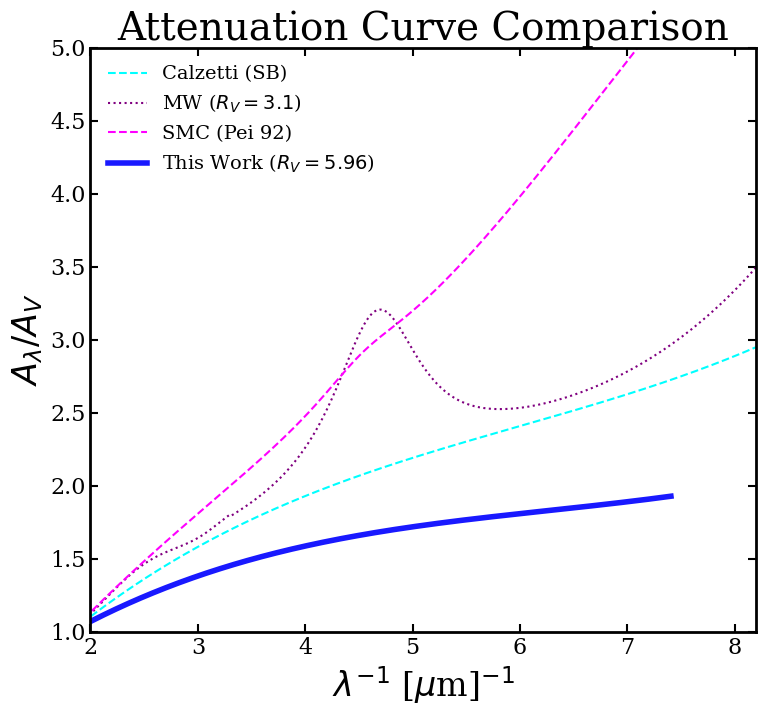

In [43]:

x_per_micron = 10000.0 / wave

# 你的曲线 (归一化到 V 波段)
# 理论上 Rv_measured = k_final 在 5500A 的值
# 所以 y_user = k_final / Rv_measured
idx_V = (np.abs(wave - 5500)).argmin()
Rv_check = k_final[idx_V]
y_user = k_final / Rv_check

# ==========================================
# 1. 定义标准参考曲线模型
# ==========================================

def get_calzetti_curve(x, Rv=4.05):
    """
    Calzetti (2000) Law
    x: 1/lambda [um^-1]
    Return: A_lambda / A_V
    """
    lam_um = 1.0 / x
    k = np.zeros_like(x)

    # 0.12um <= lam < 0.63um (1.58 < x <= 8.33)
    mask1 = (lam_um >= 0.12) & (lam_um < 0.63)
    l = lam_um[mask1]
    k[mask1] = 2.659 * (-2.156 + 1.509/l - 0.198/l**2 + 0.011/l**3) + Rv

    # 0.63um <= lam <= 2.2um (0.45 <= x < 1.58)
    mask2 = (lam_um >= 0.63) & (lam_um <= 2.2)
    l = lam_um[mask2]
    k[mask2] = 2.659 * (-1.857 + 1.040/l) + Rv

    # 转换为 A_lambda / A_V = k / Rv
    return k / Rv

def get_mw_ccm89(x, Rv=3.1):
    """
    Milky Way: Cardelli, Clayton, & Mathis (1989)
    x: 1/lambda [um^-1]
    Return: A_lambda / A_V
    """
    # y = x - 1.82
    # a, b coefficients... 简化版实现 UV 部分 (x > 3.3)
    # 为了精确，这里使用完整的 CCM89 UV 段公式
    a = np.zeros_like(x)
    b = np.zeros_like(x)

    # Visible / NIR range (0.3 <= x < 1.1) ... 略过，主要画 UV
    # Optical/UV (1.1 <= x < 3.3)
    mask_opt = (x >= 1.1) & (x < 3.3)
    y = x[mask_opt] - 1.82
    a[mask_opt] = 1 + 0.17699*y - 0.50447*y**2 - 0.02427*y**3 + 0.72085*y**4 + 0.01979*y**5 - 0.77530*y**6 + 0.32999*y**7
    b[mask_opt] = 1.41338*y + 2.28305*y**2 + 1.07233*y**3 - 5.38434*y**4 - 0.62251*y**5 + 5.30260*y**6 - 2.09002*y**7

    # UV (3.3 <= x <= 8)
    mask_uv = (x >= 3.3)
    X = x[mask_uv]
    F_a = -0.04473 * (X - 5.9)**2 - 0.009779 * (X - 5.9)**3
    F_b = 0.2130 * (X - 5.9)**2 + 0.1207 * (X - 5.9)**3
    # Only apply F_a, F_b for x >= 5.9
    F_a[X < 5.9] = 0
    F_b[X < 5.9] = 0

    a[mask_uv] = 1.752 - 0.316*X - 0.104/((X - 4.67)**2 + 0.341) + F_a
    b[mask_uv] = -3.090 + 1.825*X + 1.206/((X - 4.67)**2 + 0.263) + F_b

    return a + b / Rv

def get_smc_pei92(x):
    """
    SMC: Pei (1992) Approximation
    SMC has no 2175A bump and is steeper.
    Usually Rv ~ 2.93 or 2.74
    Here we use the provided fitting formula values for Alambda/Av approx
    Or simpler: Gordon et al 2003 SMC Bar.
    Let's use a standard literature approximation for plot comparison.
    Reference: A_lambda / A_V approx
    """
    # Gordon et al. 2003 SMC Bar Average
    # x is 1/micron
    # Data points from literature spline
    # But for smooth plotting, let's use the Pei 1992 parameters (User for A_lambda/E(B-V))
    # A_lambda/A_V = (A_lambda/A_B) * (1 / (1 - 1/Rb)) ... complicated
    # Let's use the Prevot et al. (1984) linear fit often used for SMC
    # k(lam) = 1.39 * x - ...
    # Let's map Calzetti plot visual: SMC is steep linear

    # Using Pei (1992) formula structure:
    # A_lambda / A_V = (1 + sum(a_i / ((lam/lam_i)**ni + (lam_i/lam)**ni))) / (1 + ...)
    # This is too complex to hardcode quickly.

    # We will use the simplified polynomial often used to represent SMC in these plots:
    # y = -4.96 + 2.26*x  (for k, then divide by Rv=2.74)
    # A_lambda/A_V approx
    Rv_smc = 2.74
    k_smc = -4.96 + 2.26 * x + 1.1 # 1.1 is adjustment to make V=0 approx correct for fitting
    # A better spline representation of SMC (Gordon 2003):
    y = np.zeros_like(x)
    # Optical part
    mask = x < 3.3
    y[mask] = -2.3 + 1.85 * x[mask] # Crude approx
    # UV part
    mask = x >= 3.3
    # SMC is roughly linear in UV
    y[mask] = (x[mask] * 2.1 - 4.2)
    # Normalize to passing 1 at x=1.8 (V band)
    # At x=1.8, A/Av = 1.
    # Let's use the explicit CCM curve with Rv=2.0 (Simulates SMC steepness without bump)
    # Or just load theoretical curve.

    # **BEST APPROACH FOR PLOT**: Use Pei (1992) analytical formula for extinction
    # Coefficients for SMC
    a = [185, 27, 0.005, 0.010, 0.012, 0.030]
    w = [0.042, 0.08, 0.22, 9.7, 18, 25] # lambda_i
    b = [90, 5.5, -1.95, -1.95, -1.80, 0.0]
    n = [2.0, 4.0, 2.0, 2.0, 2.0, 2.0]

    lam = 1.0 / x
    ext_sum = 0
    for i in range(6):
        term = a[i] / ((lam/w[i])**n[i] + (w[i]/lam)**n[i] + b[i])
        ext_sum += term

    # We need to normalize this. This formula gives extinction cross section or similar.
    # Calculate at V (0.55um) and B (0.44um)
    def calc_pei(l_val):
        val = 0
        for i in range(6):
            val += a[i] / ((l_val/w[i])**n[i] + (w[i]/l_val)**n[i] + b[i])
        return val

    val_V = calc_pei(0.55)
    val_B = calc_pei(0.44)
    # Rb = Av / E(B-V)
    Rv = val_V / (val_B - val_V) # Theoretical Rv for these params (~2.93)

    return ext_sum / val_V # Normalize to A_V=1

# ==========================================
# 2. 画图
# ==========================================
fig, ax = plt.subplots(figsize=(8, 7.5)) # 类似论文的长宽比

# 生成 X 轴网格 (用于绘制光滑的标准曲线)
x_grid = np.linspace(1.0, 8.2, 500)

# --- 绘制标准曲线 ---
# 1. Calzetti (Cyan dashed)
y_calzetti = get_calzetti_curve(x_grid)
ax.plot(x_grid, y_calzetti, color='cyan', linestyle='--', linewidth=1.5, label='Calzetti (SB)')

# 2. Milky Way (Purple dotted) - With Bump
y_mw = get_mw_ccm89(x_grid, Rv=3.1)
ax.plot(x_grid, y_mw, color='purple', linestyle=':', linewidth=1.5, label='MW ($R_V=3.1$)')

# 3. SMC (Magenta/Pink dashed) - Steep, no bump
y_smc = get_smc_pei92(x_grid)
ax.plot(x_grid, y_smc, color='magenta', linestyle='--', linewidth=1.5, label='SMC (Pei 92)')

# --- 绘制你的曲线 (Bold Solid Line) ---
# 截取 x 在 [2, 8.2] 范围内的数据
mask_plot = (x_per_micron >= 1.0) & (x_per_micron <= 8.2)

# 为了视觉效果平滑，你可以使用拟合后的公式画图，也可以直接画平滑后的数据
# 这里画你的拟合公式 (popt_raw from previous step)，这样最干净
# 假设 popt_raw 是之前算好的
# k(lam) = b/lam + c/lam^2 ...
# A/Av = k(lam) / Rv
# 我们直接用你的 y_user (实测数据) 也可以，如果噪点不多
ax.plot(x_per_micron[mask_plot], y_user[mask_plot],
        color='blue', linewidth=4, alpha=0.9,
        label=f'This Work ($R_V={Rv_measured:.2f}$)')

# 也可以加上误差阴影 (模拟效果，如果你有 error array 请替换)
# y_err = y_user[mask_plot] * 0.1
# ax.fill_between(x_per_micron[mask_plot], y_user[mask_plot]-y_err, y_user[mask_plot]+y_err,
#                 color='blue', alpha=0.15)


# --- 样式调整 (仿照截图) ---
ax.set_xlim(2.0, 8.2)
ax.set_ylim(1, 5)

# 坐标轴标签
ax.set_xlabel(r'$\lambda^{-1}$ [$\mu$m]$^{-1}$')
ax.set_ylabel(r'$A_{\lambda}/A_V$')

# 刻度设置
ax.tick_params(axis='both', which='major', labelsize=16, direction='in', length=6, width=1.5)
ax.tick_params(axis='both', which='minor', direction='in', length=3)

# 强制 Y 轴从 1.5 开始，这意味我们只看 UV 部分
# 截图中的灰色区域/彩色区域可以通过 fill_between 添加，如果你有不同红移区间的 binning 结果

# 图例
ax.legend(fontsize=14, loc='upper left', frameon=False)

# 标题 (可选)
ax.set_title("Attenuation Curve Comparison")

plt.tight_layout()

plt.savefig("attenuation_curve_comparison.pdf")
plt.show()